## Parte I — 04. Análise Gráfica

**Unidade Curricular:** Laboratório de Análise de Dados  
**Dataset:** NBA Stats (1947–2026) — [Kaggle](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats)  

---

### Objectivos deste Notebook

Explorar visualmente o dataset enriquecido através de gráficos elaborados que contam histórias com os dados. Ao contrário do notebook 02 onde os gráficos eram auxiliares à análise estatística, aqui os gráficos são o produto final.

1. Histogramas — distribuições das principais variáveis, comparando All-Stars vs. restantes  
2. Boxplots — dispersão e outliers por posição, era e nível de jogador  
3. Scatter plots — relações entre variáveis com múltiplas dimensões codificadas  
4. Heatmaps — padrões em grelha por posição, era e equipa  
5. Evolução temporal — tendências históricas com marcos anotados  
6. Rankings top 10 — melhores jogadores e equipas da história  
7. Análise de All-Stars e MVP — reconhecimento individual em detalhe  
8. Análise crítica — conclusões visuais  

---
## Imports e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Paths
OUTPUT_DIR = './outputs/'
DATA_DIR   = './data/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Estilo dos gráficos
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f8f8',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
})
PALETTE = ['#C9082A', '#1D428A', '#FFC72C', '#007A33', '#552583']

# Carregar Dataset Principal
enriched_path = f'{OUTPUT_DIR}dataset_nba_enriched.csv'
if os.path.exists(enriched_path):
    df = pd.read_csv(enriched_path, low_memory=False)
    print('Dataset enriquecido carregado')
else:
    df = pd.read_csv(f'{OUTPUT_DIR}dataset_nba.csv', low_memory=False)
    print('Dataset base carregado')

# Carregar All-Stars 
allstar_df = pd.read_csv(f'{DATA_DIR}All-Star Selections.csv', low_memory=False)
allstar_df = allstar_df[allstar_df['lg'] == 'NBA'].copy()

df_work = df[df['g'] >= 10].copy()

as_keys = set(allstar_df['player_id'].astype(str) + "_" + allstar_df['season'].astype(str))
work_keys = df_work['player_id'].astype(str) + "_" + df_work['season'].astype(str)

df_work['is_allstar'] = work_keys.isin(as_keys).astype(int)
df_work['hof'] = df_work['hof'].fillna(0).astype(int)

print(f"All-Stars identificados: {df_work['is_allstar'].sum()}")
print(f"Registos no df_work: {len(df_work)}")

Dataset enriquecido carregado
All-Stars identificados: 1916
Registos no df_work: 28586


In [2]:
# Carregar outros ficheiros
team_df = pd.read_csv(f'{DATA_DIR}Team Summaries.csv', low_memory=False)
awards_df = pd.read_csv(f'{DATA_DIR}Player Award Shares.csv', low_memory=False)

# Filtrar apenas NBA
team_df = team_df[team_df['lg'] == 'NBA'].copy()
awards_df = awards_df[awards_df['award'].str.startswith('nba')].copy()

print("Ficheiros de Equipas e Prémios carregados com sucesso.")

Ficheiros de Equipas e Prémios carregados com sucesso.


---
## Histogramas das Distribuições

Os histogramas permitem visualizar a forma da distribuição de cada variável — se é simétrica, assimétrica, bimodal, ou com caudas longas. Comparamos sempre a distribuição dos All-Stars vs. jogadores normais para perceber o que distingue os melhores jogadores.

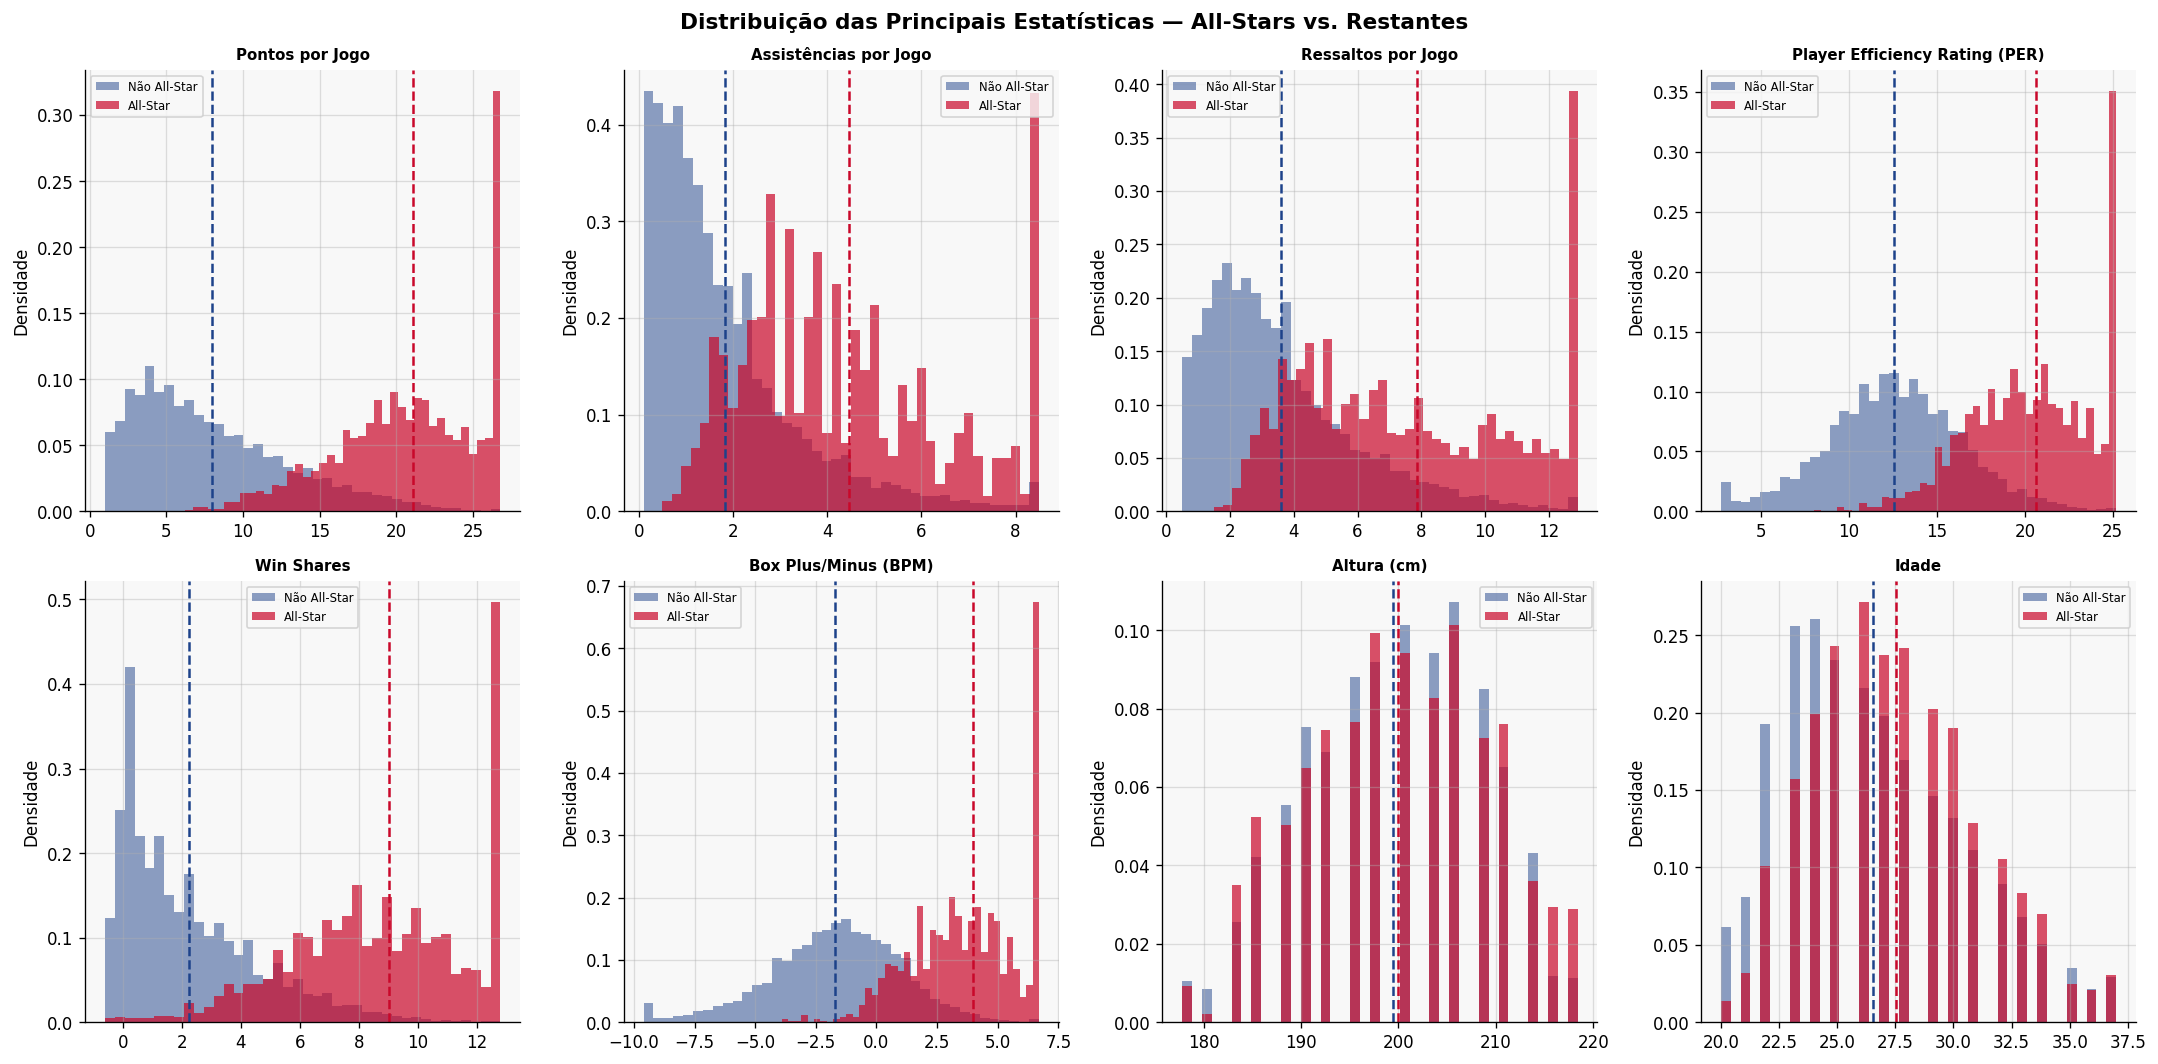

In [3]:
# Histogramas das principais estatísticas — All-Stars vs. Restantes

stats = [
    ('pts_per_game', 'Pontos por Jogo'),
    ('ast_per_game', 'Assistências por Jogo'),
    ('trb_per_game', 'Ressaltos por Jogo'),
    ('per', 'Player Efficiency Rating (PER)'),
    ('ws', 'Win Shares'),
    ('bpm', 'Box Plus/Minus (BPM)'),
    ('height_cm', 'Altura (cm)'),
    ('age', 'Idade'),
]

allstars = df_work[df_work['is_allstar'] == 1]
normais  = df_work[df_work['is_allstar'] == 0]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()


for i, (col, label) in enumerate(stats):
    ax = axes[i]

    data_n = normais[col].dropna()
    data_a = allstars[col].dropna()

    # Limitar aos percentis 1-99 para não distorcer com outliers extremos
    q01 = df_work[col].quantile(0.01)
    q99 = df_work[col].quantile(0.99)

    ax.hist(data_n.clip(q01, q99), bins=40, color=PALETTE[1], alpha=0.5, density=True, label='Não All-Star')
    ax.hist(data_a.clip(q01, q99), bins=40, color=PALETTE[0], alpha=0.7, density=True, label='All-Star')

    # Linhas de média
    ax.axvline(data_n.mean(), color=PALETTE[1], linewidth=1.5, linestyle='--')
    ax.axvline(data_a.mean(), color=PALETTE[0], linewidth=1.5, linestyle='--')

    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)

plt.suptitle('Distribuição das Principais Estatísticas — All-Stars vs. Restantes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec1_histogramas.png', bbox_inches='tight')
plt.show()

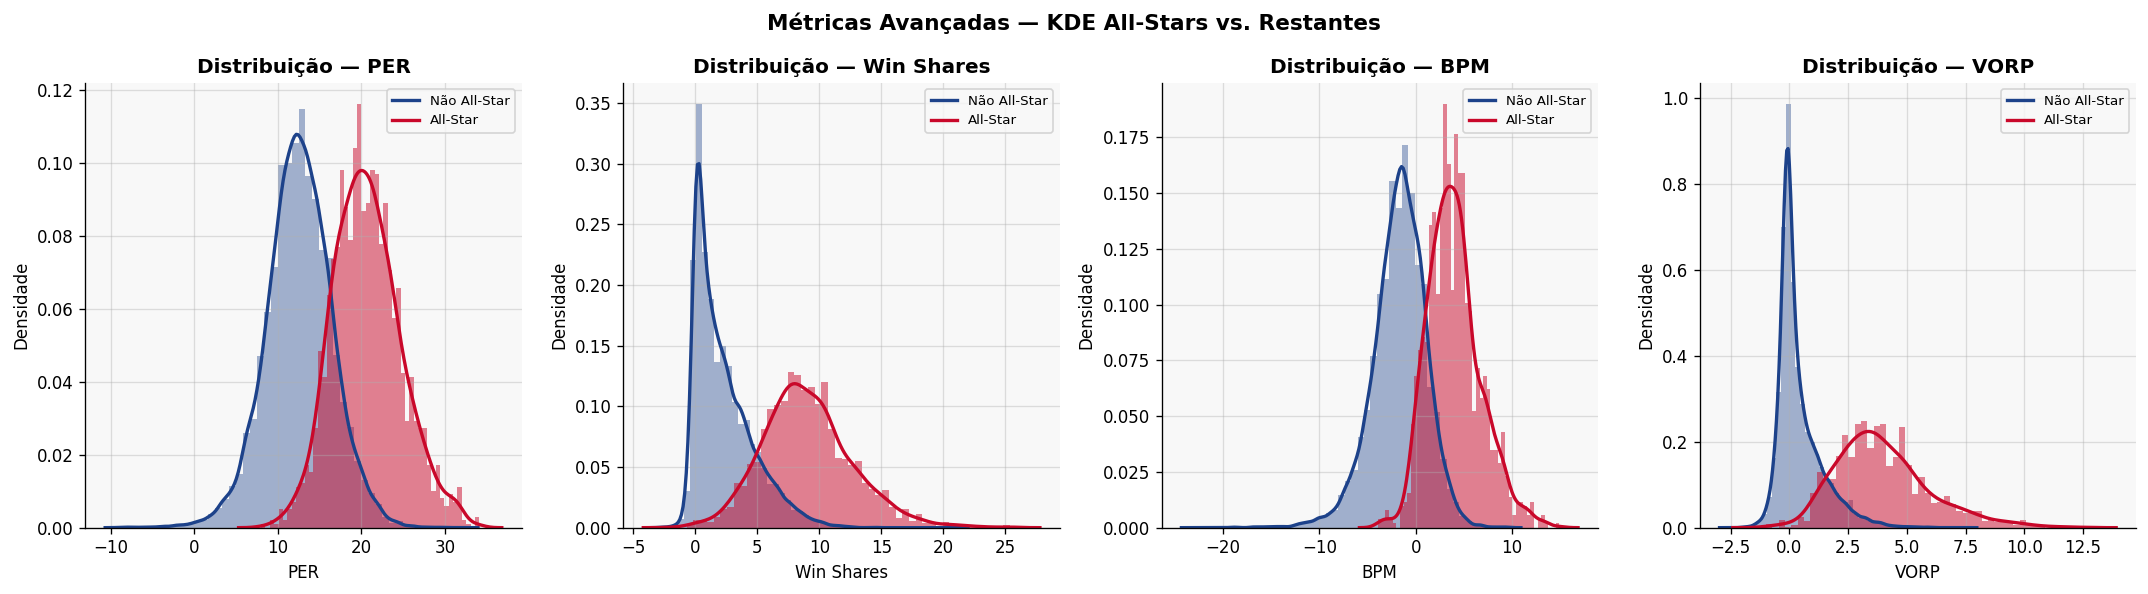

In [4]:
# Histogramas com KDE — foco nas métricas avançadas

metricas_avancadas = [
    ('per', 'PER'),
    ('ws', 'Win Shares'),
    ('bpm', 'BPM'),
    ('vorp', 'VORP'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (col, label) in enumerate(metricas_avancadas):
    ax = axes[i]
    data_n = normais[col].dropna()
    data_a = allstars[col].dropna()

    # Histograma + KDE sobreposto
    ax.hist(data_n, bins=50, color=PALETTE[1], alpha=0.4, density=True)
    ax.hist(data_a, bins=50, color=PALETTE[0], alpha=0.5, density=True)

    # KDE manual com seaborn
    sns.kdeplot(data_n, ax=ax, color=PALETTE[1], linewidth=2, label='Não All-Star')
    sns.kdeplot(data_a, ax=ax, color=PALETTE[0], linewidth=2, label='All-Star')

    ax.set_title(f'Distribuição — {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Métricas Avançadas — KDE All-Stars vs. Restantes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec1_histogramas_kde.png', bbox_inches='tight')
plt.show()

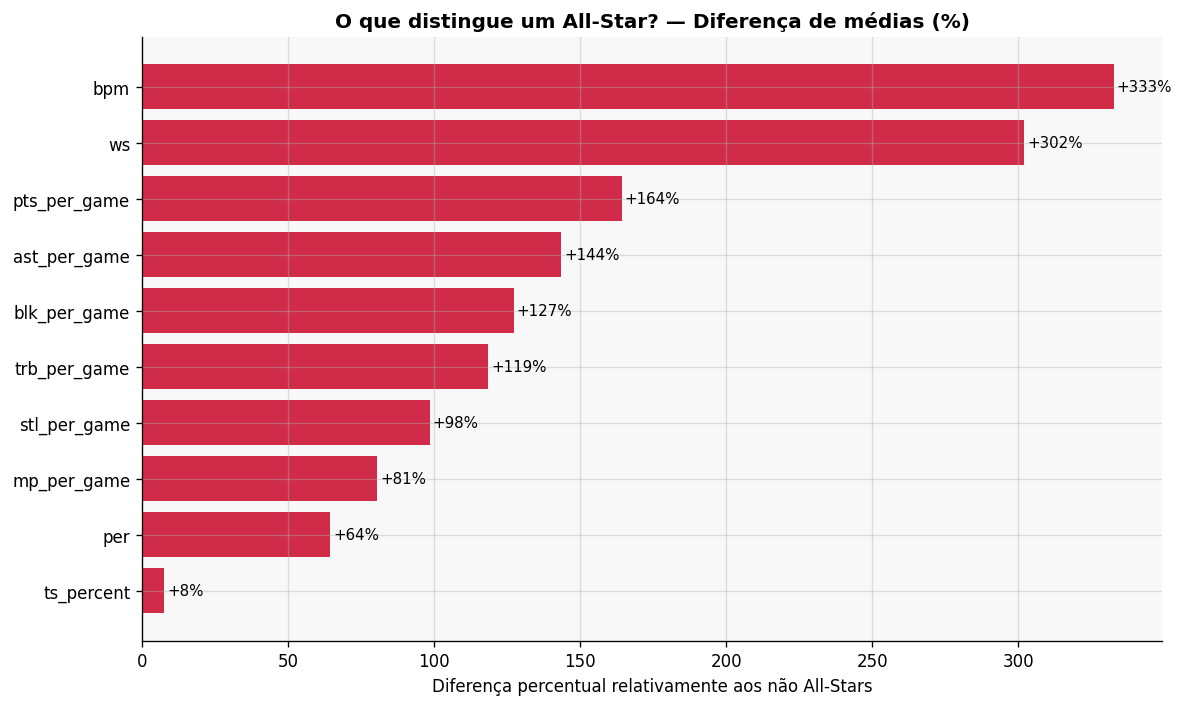

In [5]:
# Diferença de médias entre All-Stars e não All-Starss

cols_analise = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game',
                'blk_per_game', 'per', 'ws', 'bpm', 'ts_percent', 'mp_per_game']
cols_analise = [c for c in cols_analise if c in df_work.columns]

medias_allstar  = allstars[cols_analise].mean()
medias_normais  = normais[cols_analise].mean()

# Diferença percentual
diff_pct = ((medias_allstar - medias_normais) / medias_normais.abs() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[0] if v > 0 else PALETTE[1] for v in diff_pct.values]
bars = ax.barh(diff_pct.index, diff_pct.values, color=colors, alpha=0.85)

for bar, val in zip(bars, diff_pct.values):
    ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=9)

ax.axvline(x=0, color='gray', linewidth=1)
ax.set_xlabel('Diferença percentual relativamente aos não All-Stars')
ax.set_title('O que distingue um All-Star? — Diferença de médias (%)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec1_diferenca_allstar.png', bbox_inches='tight')
plt.show()

---
## Boxplots

Os boxplots mostram a mediana, quartis e outliers de cada variável. São ideais para comparar distribuições entre grupos e identificar jogadores fora do comum. Analisamos três ângulos: por posição, por década e por nível de jogador (All-Star vs. restantes).

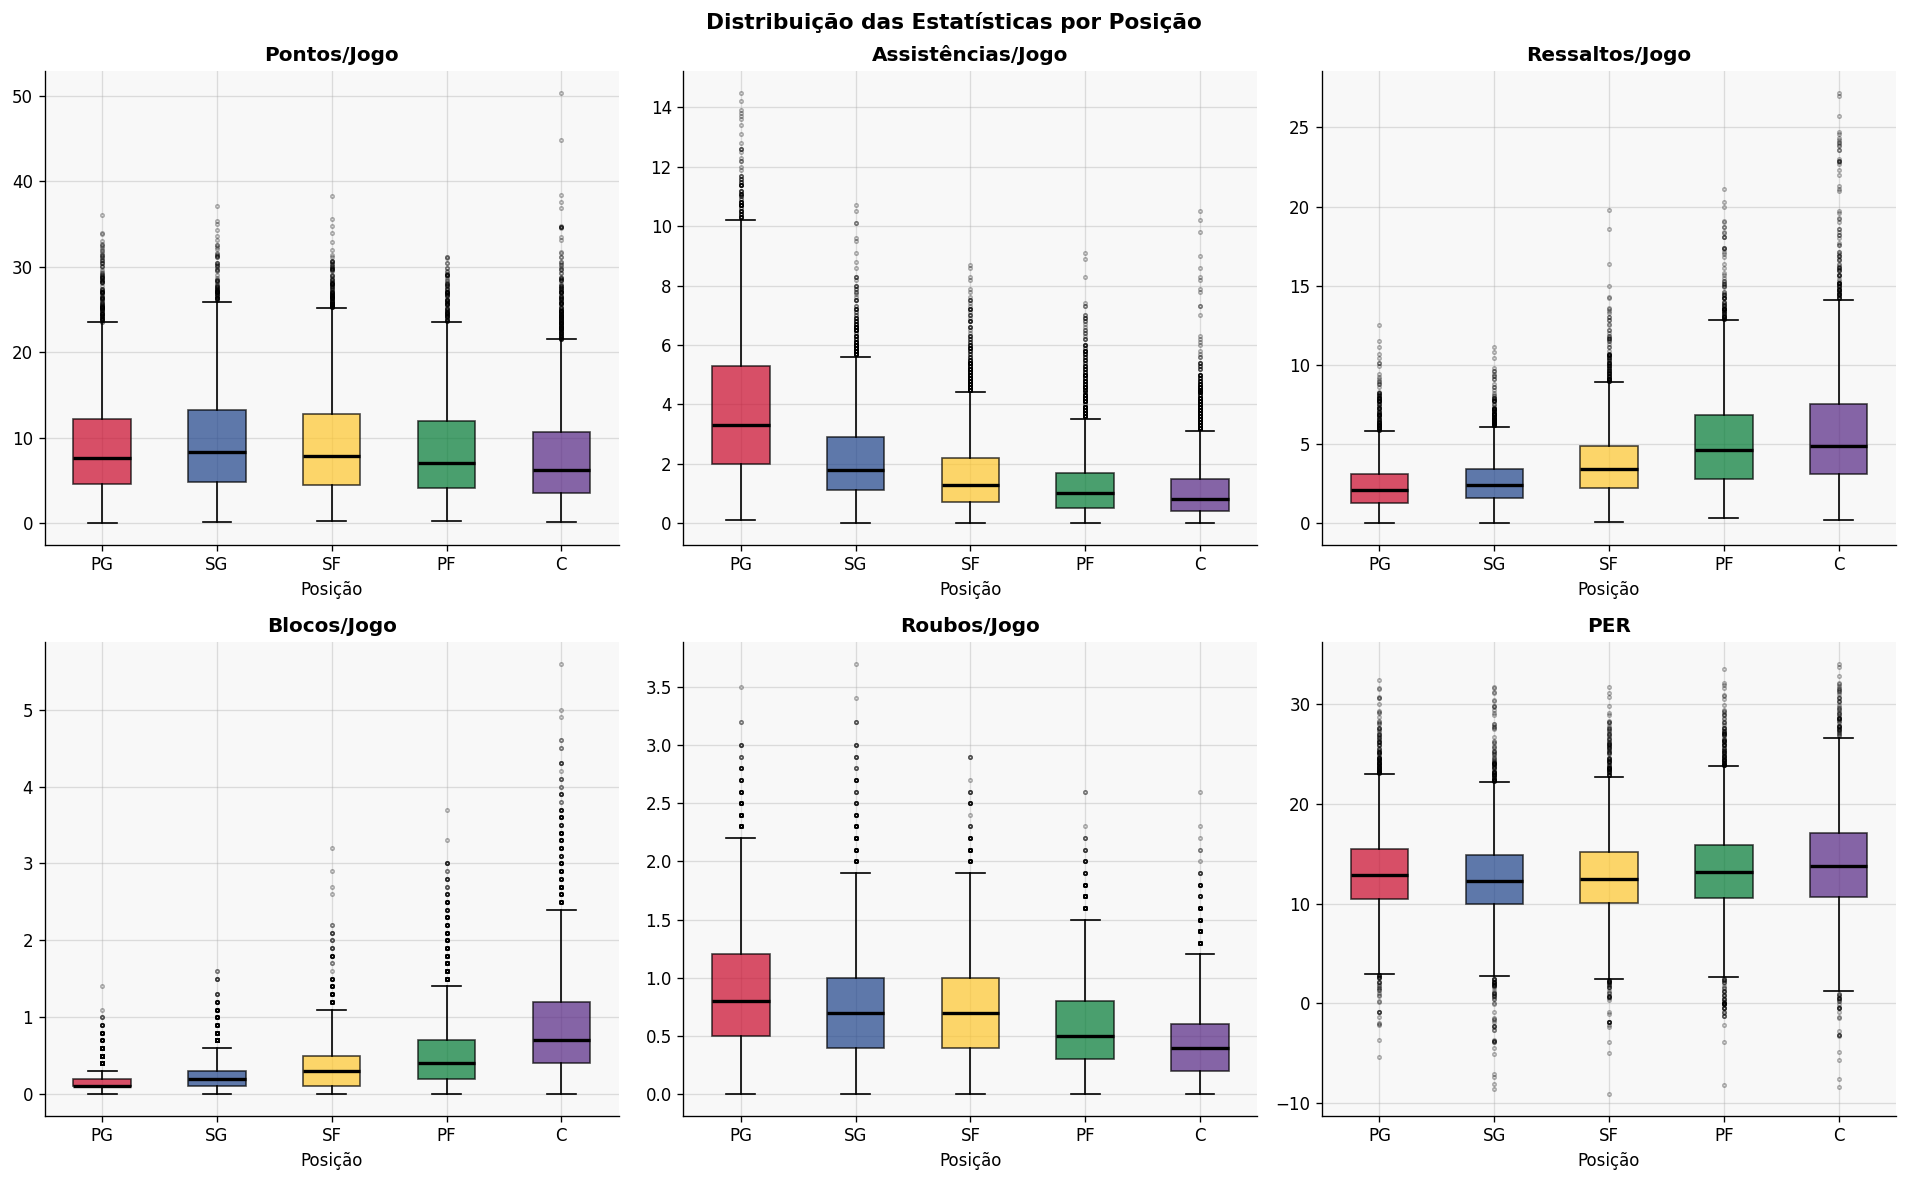

In [6]:
# Boxplots por posição — estatísticas principais

pos_order  = ['PG', 'SG', 'SF', 'PF', 'C']
pos_colors = dict(zip(pos_order, PALETTE))

stats_pos = [
    ('pts_per_game', 'Pontos/Jogo'),
    ('ast_per_game', 'Assistências/Jogo'),
    ('trb_per_game', 'Ressaltos/Jogo'),
    ('blk_per_game', 'Blocos/Jogo'),
    ('stl_per_game', 'Roubos/Jogo'),
    ('per', 'PER'),
]

df_pos = df_work[df_work['pos'].isin(pos_order)].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(stats_pos):
    ax = axes[i]
    data = [df_pos[df_pos['pos'] == p][col].dropna() for p in pos_order]
    bp = ax.boxplot(data, labels=pos_order, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, pos in zip(bp['boxes'], pos_order):
        patch.set_facecolor(pos_colors[pos])
        patch.set_alpha(0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Posição')

plt.suptitle('Distribuição das Estatísticas por Posição', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec2_boxplot_posicao.png', bbox_inches='tight')
plt.show()

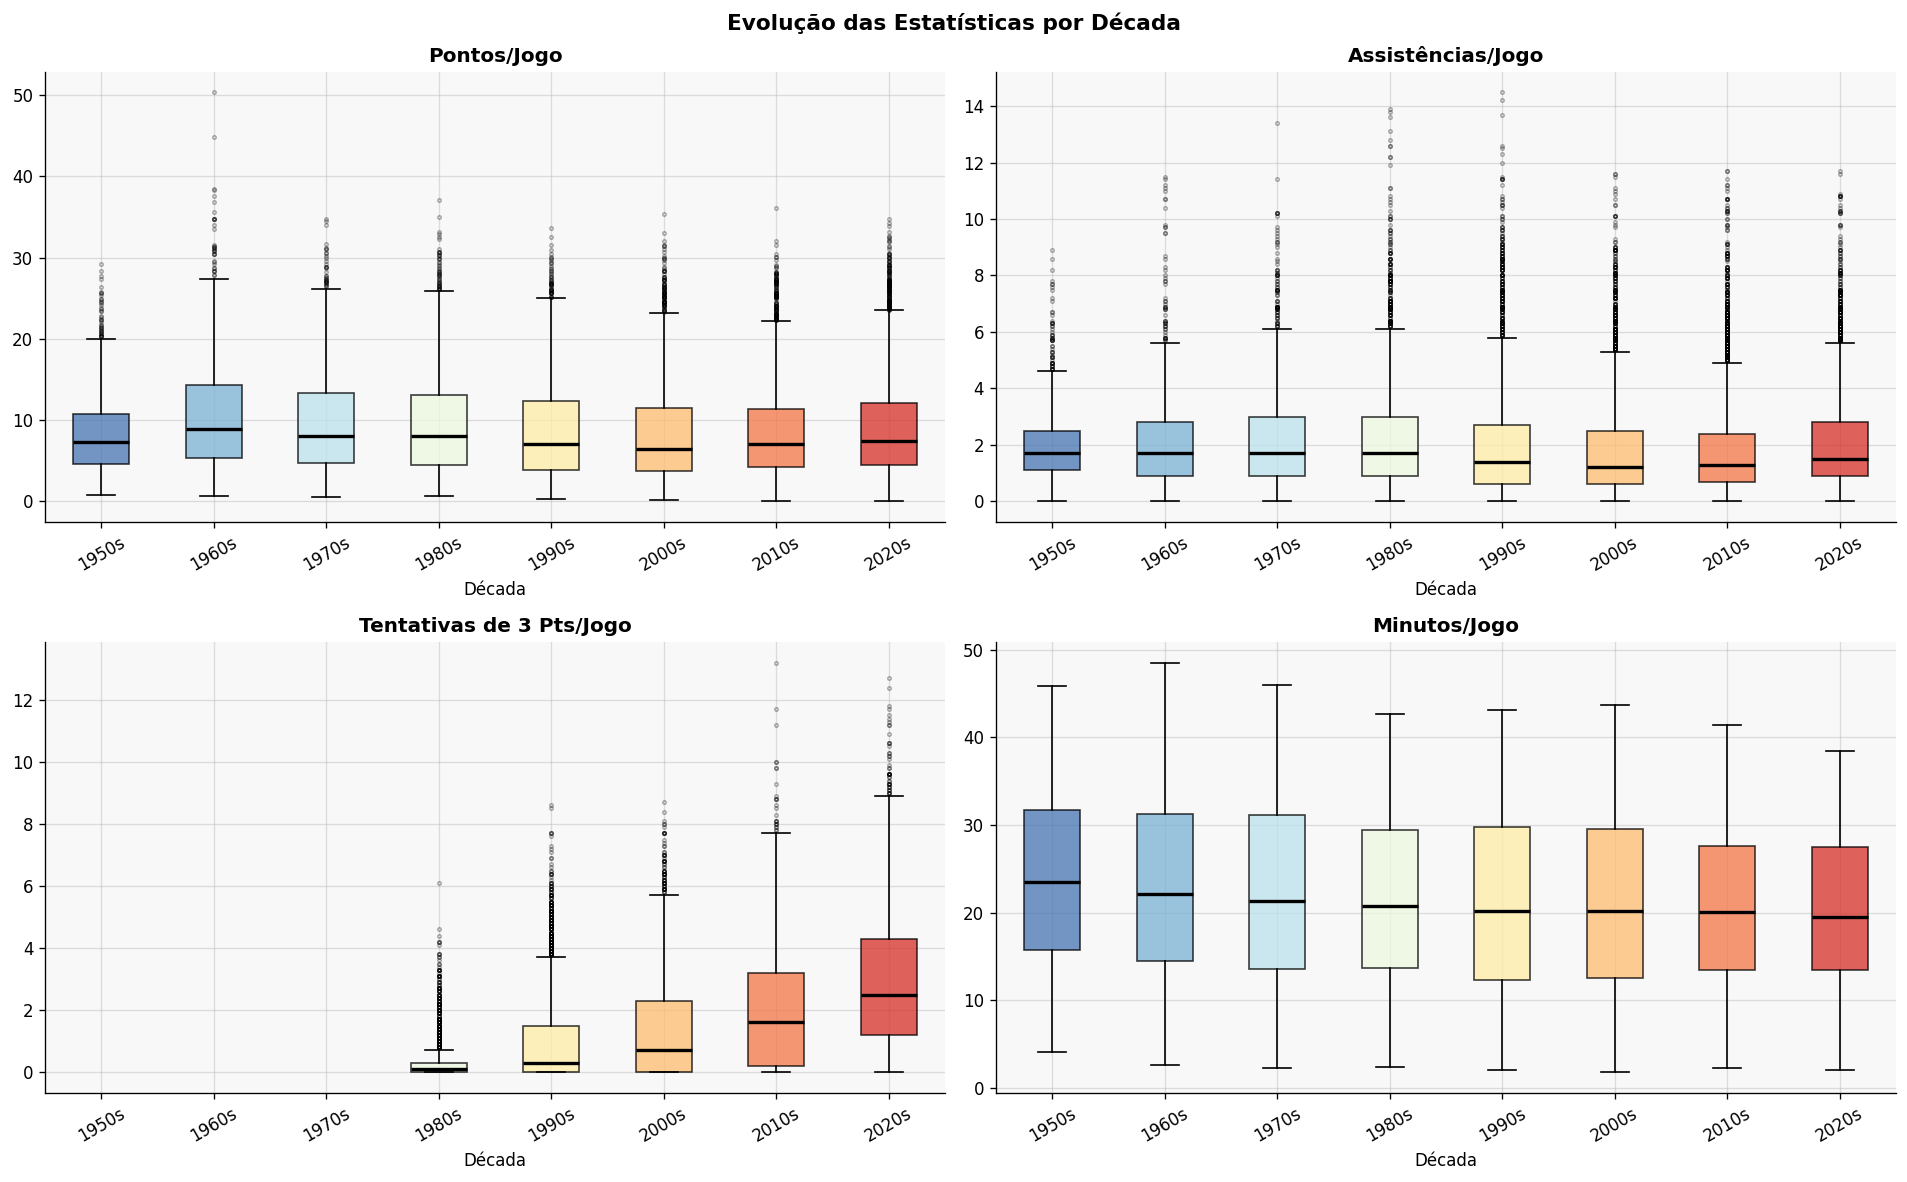

In [7]:
# Boxplots por década — como evoluiu o jogo ao longo do tempo?

decadas = ['1950s','1960s','1970s','1980s','1990s','2000s','2010s','2020s']
dec_colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(decadas)))

stats_dec = [
    ('pts_per_game', 'Pontos/Jogo'),
    ('ast_per_game', 'Assistências/Jogo'),
    ('x3pa_per_game', 'Tentativas de 3 Pts/Jogo'),
    ('mp_per_game', 'Minutos/Jogo'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(stats_dec):
    ax = axes[i]
    data = [df_work[df_work['decade'] == d][col].dropna() for d in decadas]
    bp = ax.boxplot(data, labels=decadas, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], dec_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Década')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Evolução das Estatísticas por Década', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec2_boxplot_decada.png', bbox_inches='tight')
plt.show()

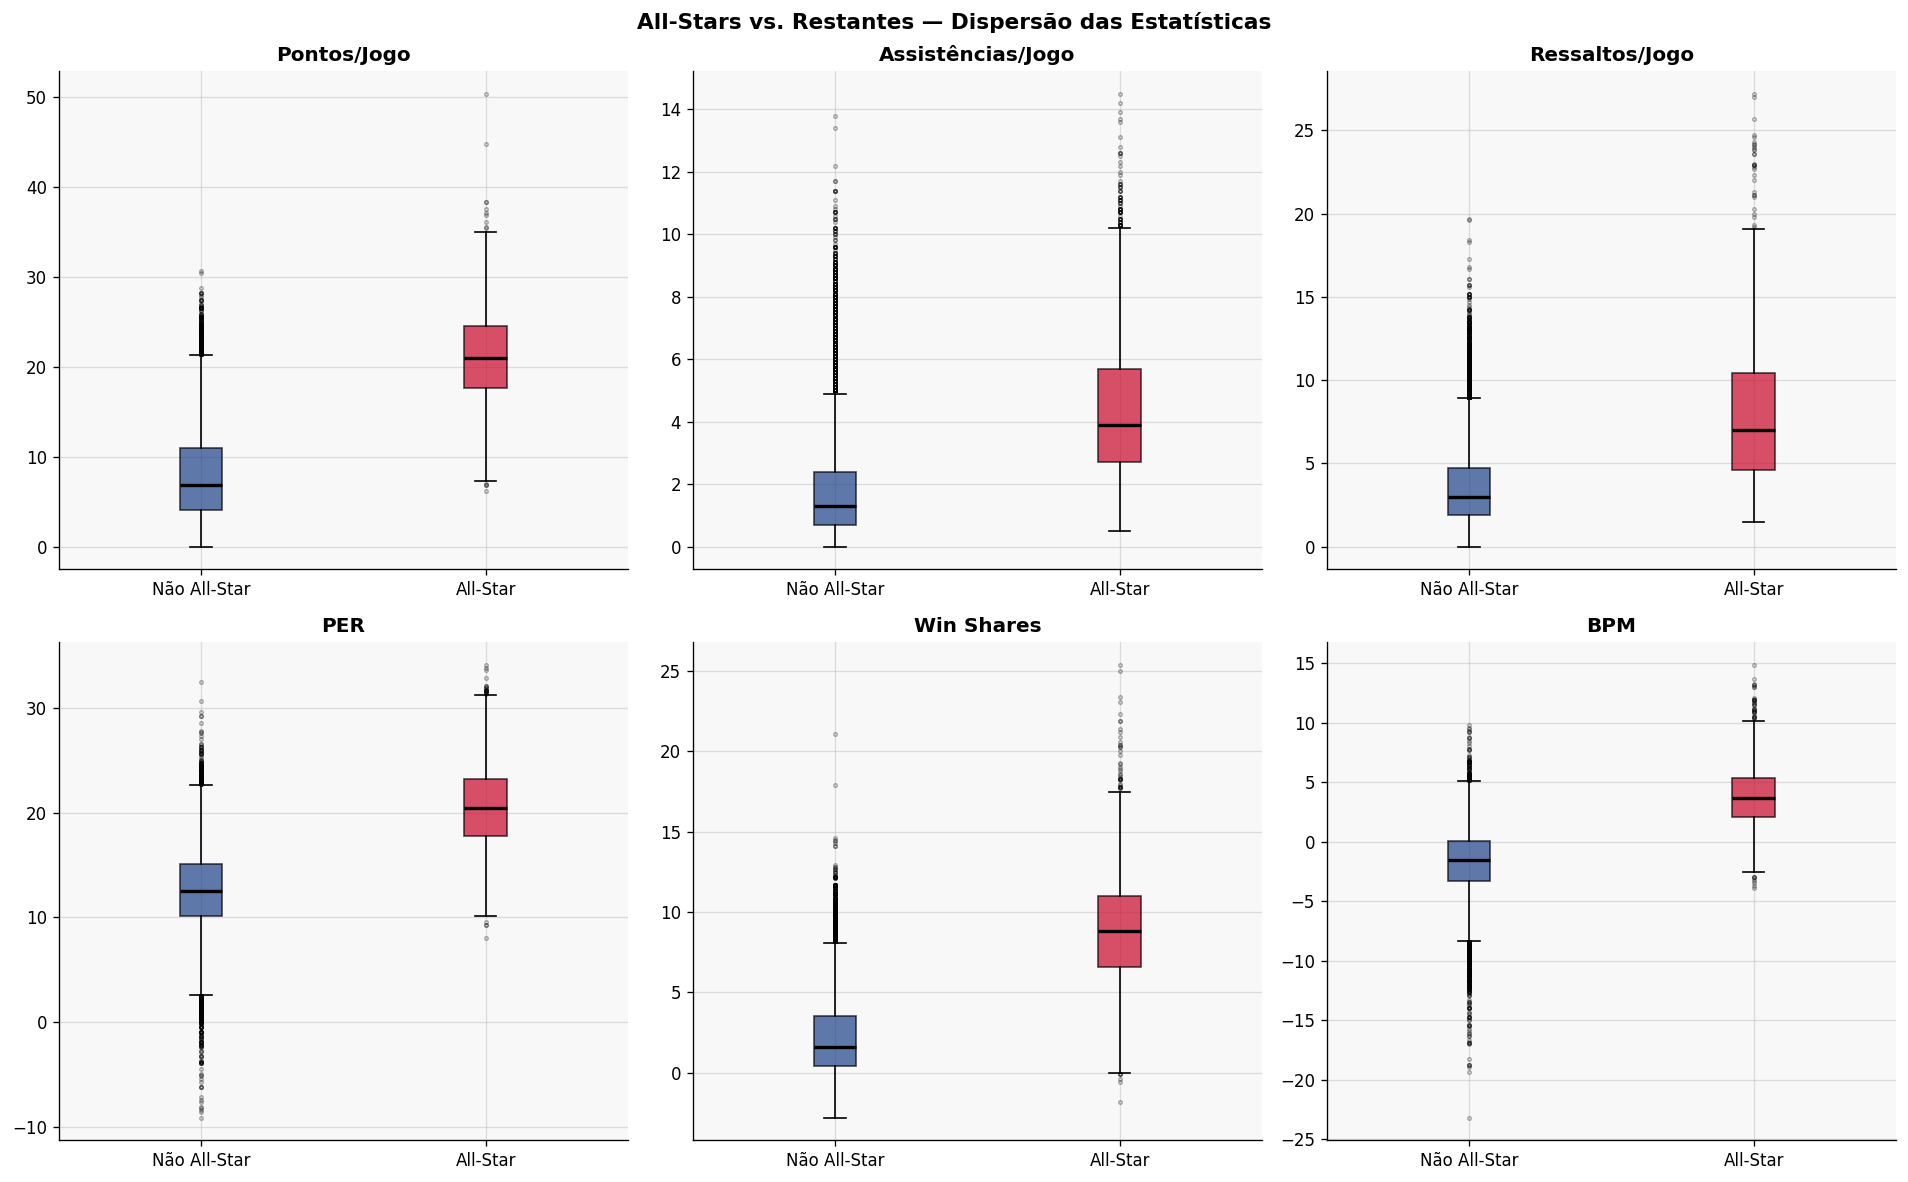

In [8]:
# Boxplots All-Stars vs. Não All-Stars — quão superiores são os All-Stars?

allstars = df_work[df_work['is_allstar'].astype(bool) == True]
normais  = df_work[df_work['is_allstar'].astype(bool) == False]

stats_as = [
    ('pts_per_game', 'Pontos/Jogo'),
    ('ast_per_game', 'Assistências/Jogo'),
    ('trb_per_game', 'Ressaltos/Jogo'),
    ('per', 'PER'),
    ('ws', 'Win Shares'),
    ('bpm', 'BPM'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(stats_as):
    ax = axes[i]
    data = [normais[col].dropna(), allstars[col].dropna()]
    bp = ax.boxplot(data, labels=['Não All-Star', 'All-Star'], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    bp['boxes'][0].set_facecolor(PALETTE[1])
    bp['boxes'][1].set_facecolor(PALETTE[0])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    ax.set_title(label, fontweight='bold')

plt.suptitle('All-Stars vs. Restantes — Dispersão das Estatísticas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec2_boxplot_allstar.png', bbox_inches='tight')
plt.show()

---
## Scatter Plots

Os scatter plots permitem visualizar relações entre duas variáveis em simultâneo. Aqui usamos uma terceira variável codificada em cor para adicionar mais uma dimensão de informação, e anotamos os outliers históricos mais famosos.

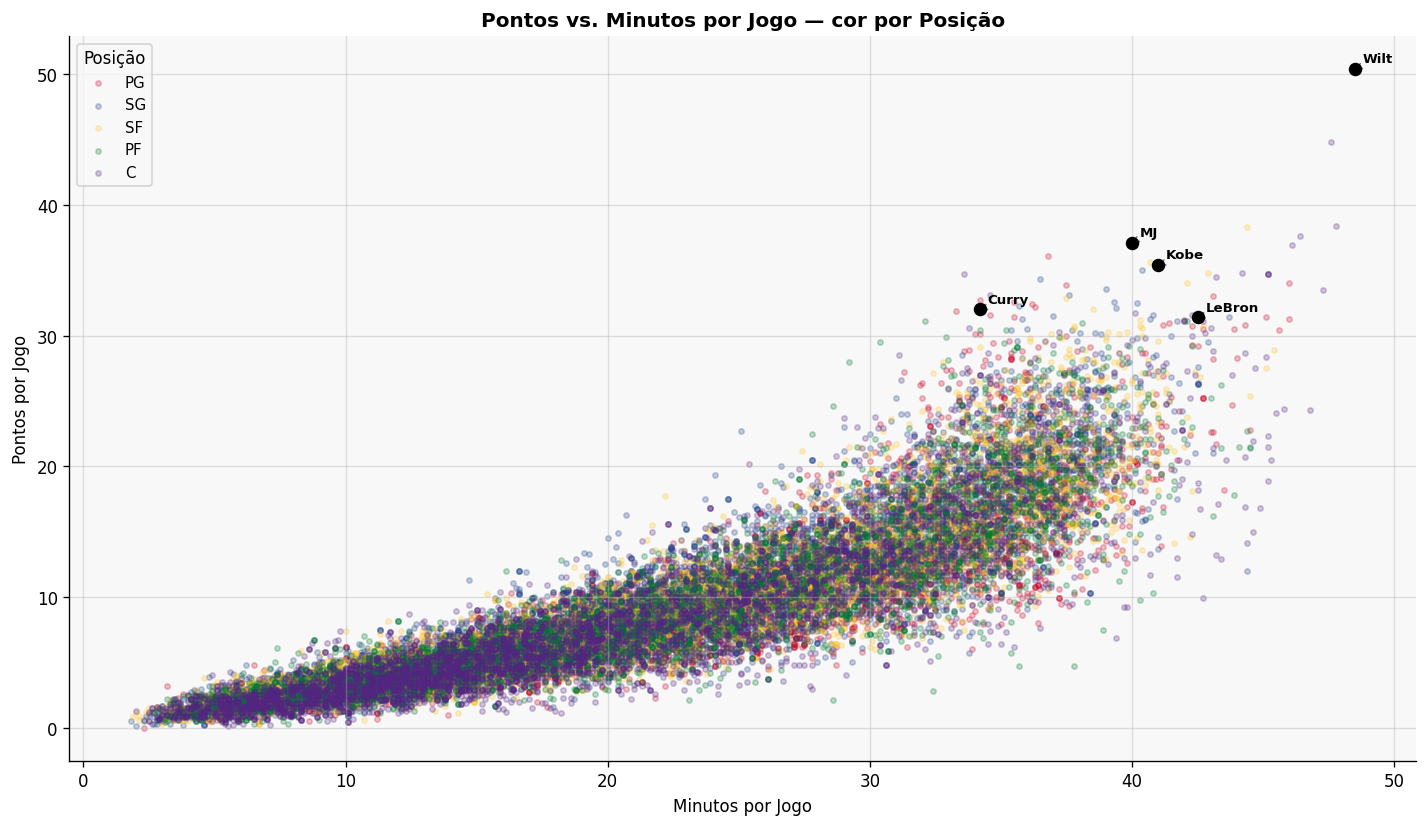

In [9]:
# Pontos vs. Minutos
# Mostra que jogadores com mais minutos tendem a pontuar mais, mas alguns bases e extremos pontuam muito com poucos minutos

pos_order  = ['PG', 'SG', 'SF', 'PF', 'C']
pos_colors = dict(zip(pos_order, PALETTE))

df_scatter = df_work[df_work['pos'].isin(pos_order)].dropna(subset=['pts_per_game','mp_per_game'])

fig, ax = plt.subplots(figsize=(12, 7))

for pos in pos_order:
    sub = df_scatter[df_scatter['pos'] == pos]
    ax.scatter(sub['mp_per_game'], sub['pts_per_game'], color=pos_colors[pos], alpha=0.25, s=10, label=pos)

# Anotar os outliers históricos mais famosos
famosos = {
    'Michael Jordan': (1987, 'MJ'),
    'Wilt Chamberlain': (1962, 'Wilt'),
    'Kobe Bryant': (2006, 'Kobe'),
    'LeBron James': (2006, 'LeBron'),
    'Stephen Curry': (2021, 'Curry'),
}
for nome, (season, label) in famosos.items():
    row = df_work[(df_work['player'] == nome) & (df_work['season'] == season)]
    if len(row) > 0:
        x = row['mp_per_game'].values[0]
        y = row['pts_per_game'].values[0]
        ax.annotate(label, xy=(x, y), xytext=(x+0.3, y+0.5),
                    fontsize=8, fontweight='bold', color='black',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1))
        ax.scatter(x, y, color='black', s=50, zorder=5)

ax.set_xlabel('Minutos por Jogo')
ax.set_ylabel('Pontos por Jogo')
ax.set_title('Pontos vs. Minutos por Jogo — cor por Posição', fontweight='bold', fontsize=12)
ax.legend(title='Posição', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec3_scatter_pts_mp.png', bbox_inches='tight')
plt.show()

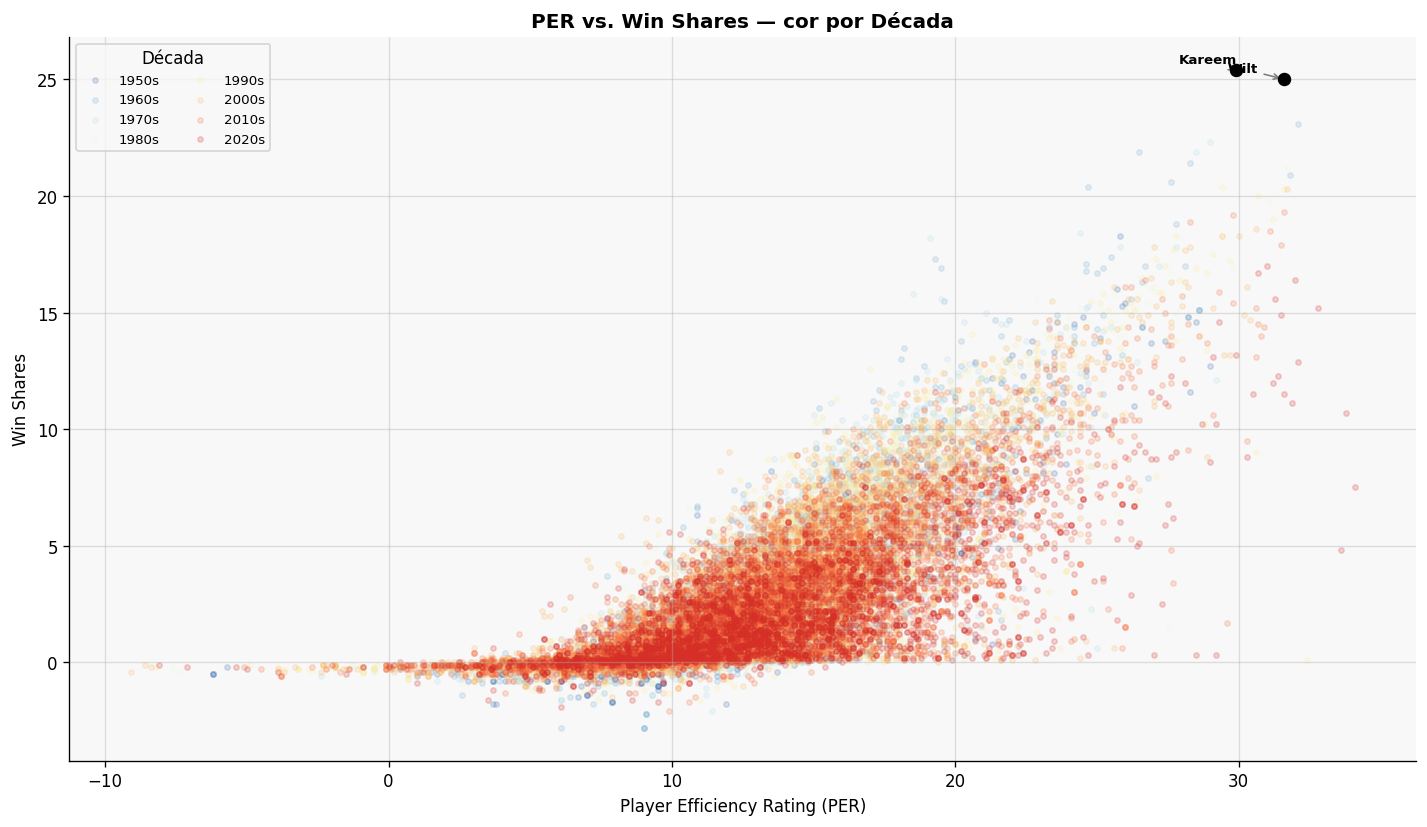

In [10]:
# PER vs. Win Shares
# PER mede eficiência individual; Win Shares mede contribuição para vitórias.

df_adv = df_work.dropna(subset=['per', 'ws']).copy()
decadas = sorted(df_adv['decade'].dropna().unique())
dec_palette = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(decadas)))
dec_colors  = dict(zip(decadas, dec_palette))

fig, ax = plt.subplots(figsize=(12, 7))

for dec in decadas:
    sub = df_adv[df_adv['decade'] == dec]
    ax.scatter(sub['per'], sub['ws'], color=dec_colors[dec], alpha=0.2, s=10, label=dec)

# Anotar os maiores outliers 
top_ws = df_adv.nlargest(6, 'ws')[['player','season','per','ws']]
anotados = set()
for _, row in top_ws.iterrows():
    chave = row['player']
    if chave not in anotados:
        nome_curto = row['player'].split()[0]  # só o primeiro nome
        ax.annotate(nome_curto, xy=(row['per'], row['ws']),
                    xytext=(row['per'] - 2, row['ws'] + 0.3),
                    fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1))
        ax.scatter(row['per'], row['ws'], color='black', s=50, zorder=5)
        anotados.add(chave)

ax.set_xlabel('Player Efficiency Rating (PER)')
ax.set_ylabel('Win Shares')
ax.set_title('PER vs. Win Shares — cor por Década', fontweight='bold', fontsize=12)
ax.legend(title='Década', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec3_scatter_per_ws.png', bbox_inches='tight')
plt.show()

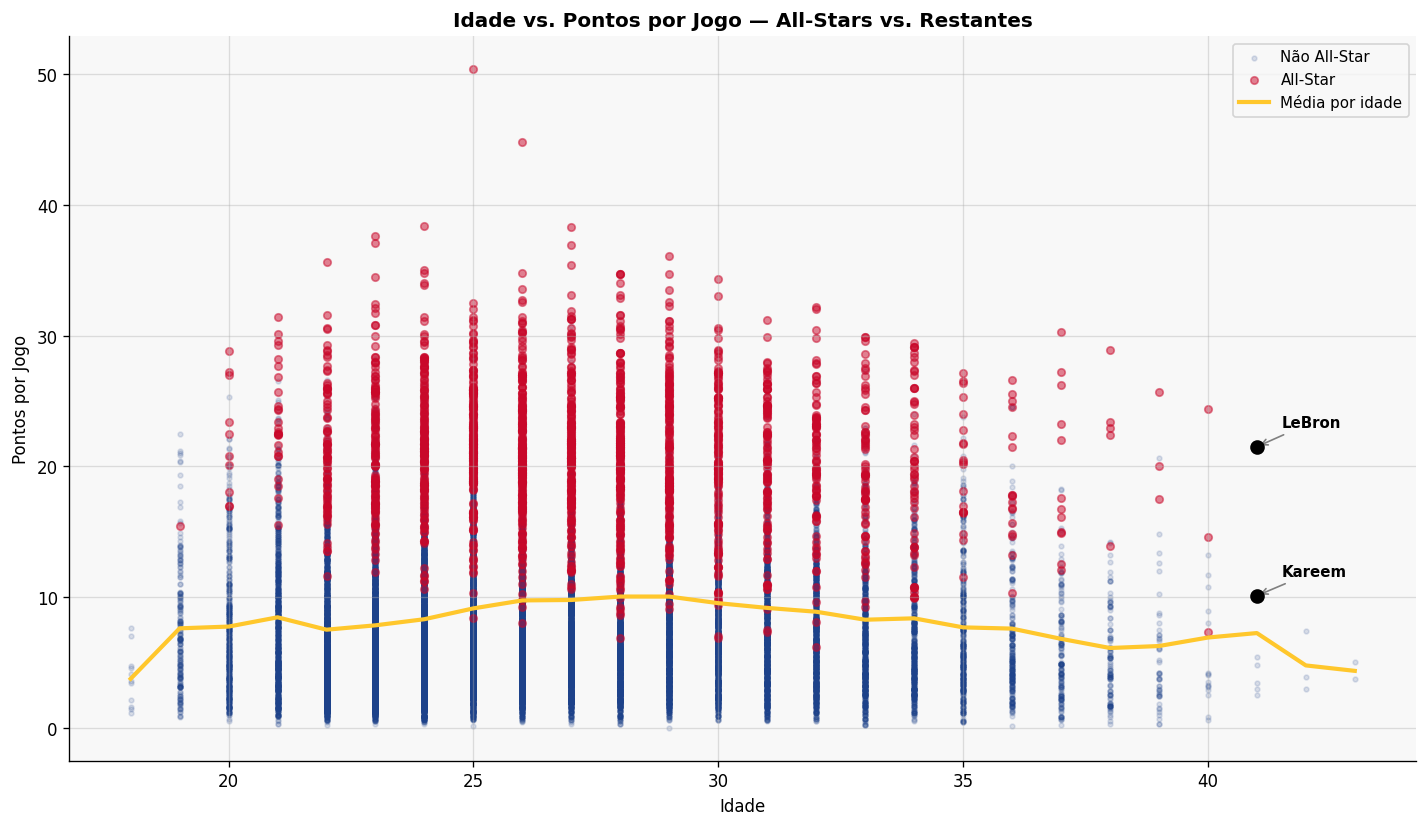

In [11]:
# Idade vs. Pontos
# Mostra o ciclo de vida de um jogador NBA — pico entre os 24-28 anos e como os All-Stars mantêm a produção por mais tempo

df_age = df_work.dropna(subset=['age', 'pts_per_game']).copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Não All-Stars
sub_n = df_age[df_age['is_allstar'].astype(bool) == False]
ax.scatter(sub_n['age'], sub_n['pts_per_game'], color=PALETTE[1], alpha=0.15, s=8, label='Não All-Star')

# All-Stars
sub_a = df_age[df_age['is_allstar'].astype(bool) == True]
ax.scatter(sub_a['age'], sub_a['pts_per_game'], color=PALETTE[0], alpha=0.5, s=20, label='All-Star')

# Linha de tendência — média de pontos por idade (só não All-Stars)
media_por_idade = df_age.groupby('age')['pts_per_game'].mean()
ax.plot(media_por_idade.index, media_por_idade.values, color=PALETTE[2], linewidth=2.5, zorder=5, label='Média por idade')

# Anotar casos famosos de longevidade
longevos = {'LeBron James': 'LeBron', 'Kareem Abdul-Jabbar': 'Kareem'}
for nome, label in longevos.items():
    rows = df_work[df_work['player'] == nome].nlargest(1, 'age')
    if len(rows) > 0:
        x, y = rows['age'].values[0], rows['pts_per_game'].values[0]
        ax.annotate(label, xy=(x, y), xytext=(x+0.5, y+1.5), fontsize=9, fontweight='bold', arrowprops=dict(arrowstyle='->', color='gray', lw=1))
        ax.scatter(x, y, color='black', s=60, zorder=6)

ax.set_xlabel('Idade')
ax.set_ylabel('Pontos por Jogo')
ax.set_title('Idade vs. Pontos por Jogo — All-Stars vs. Restantes', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec3_scatter_idade_pts.png', bbox_inches='tight')
plt.show()

---
## Heatmaps

Os heatmaps representam valores numa grelha bidimensional onde a cor indica a magnitude. São ideais para identificar padrões entre duas variáveis categóricas — como a evolução do perfil de cada posição ao longo das décadas, ou quais as equipas mais dominantes da história.

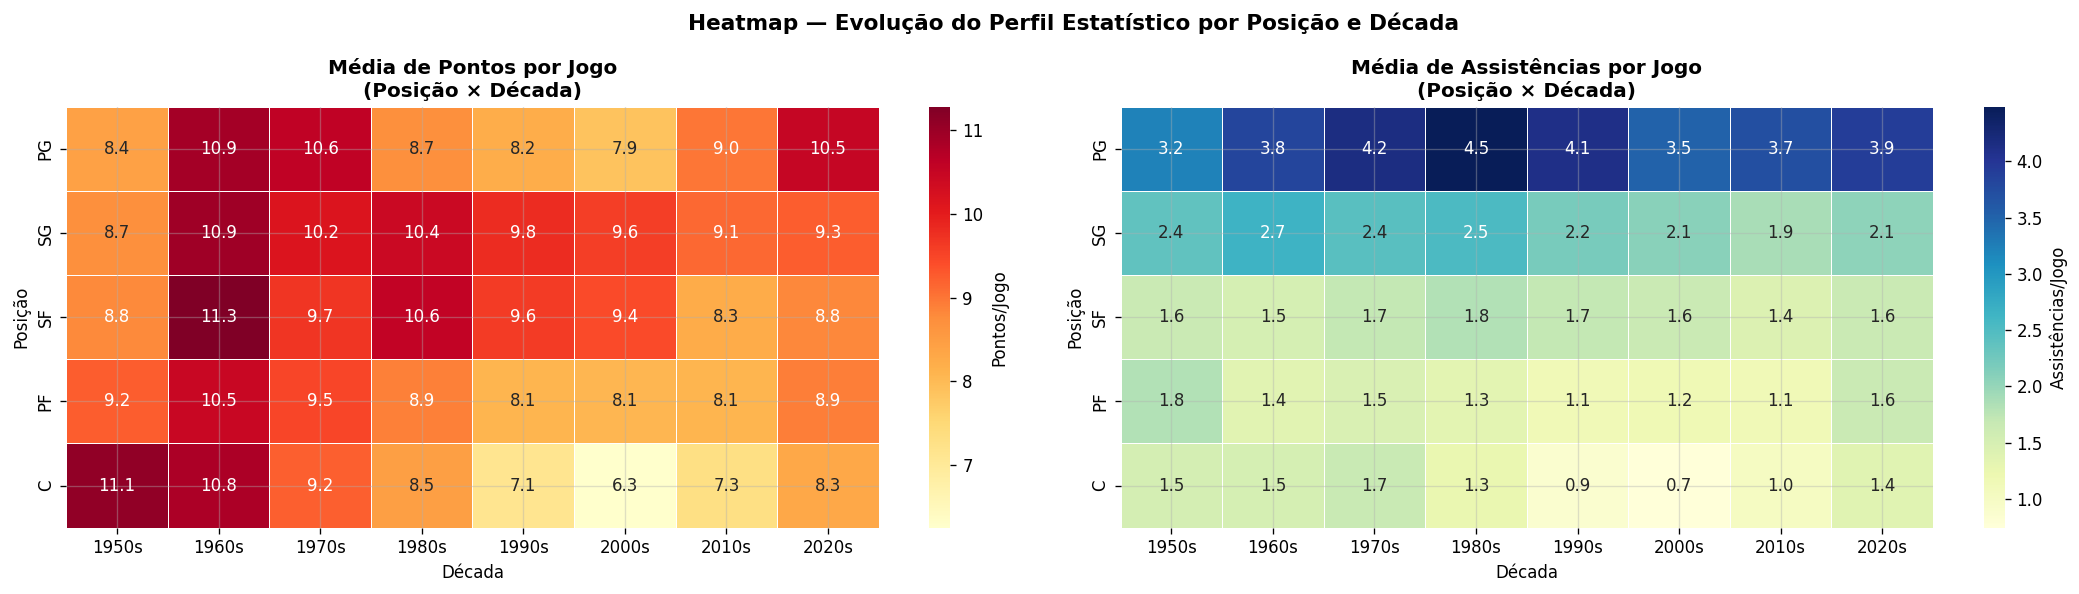

In [12]:
# Média de pontos por Posição e Década
# Mostra como o perfil ofensivo de cada posição evoluiu ao longo do tempo

pos_order = ['PG', 'SG', 'SF', 'PF', 'C']
decadas = ['1950s','1960s','1970s','1980s','1990s','2000s','2010s','2020s']

df_pos = df_work[df_work['pos'].isin(pos_order)].copy()

# Calcular médias para cada combinação posição × década
pivot_pts = df_pos.groupby(['pos','decade'])['pts_per_game'].mean().unstack()
pivot_pts = pivot_pts.reindex(index=pos_order, columns=decadas)

pivot_ast = df_pos.groupby(['pos','decade'])['ast_per_game'].mean().unstack()
pivot_ast = pivot_ast.reindex(index=pos_order, columns=decadas)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_pts, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Pontos/Jogo'}, ax=axes[0])
axes[0].set_title('Média de Pontos por Jogo\n(Posição × Década)', fontweight='bold')
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Posição')

sns.heatmap(pivot_ast, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Assistências/Jogo'}, ax=axes[1])
axes[1].set_title('Média de Assistências por Jogo\n(Posição × Década)', fontweight='bold')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Posição')

plt.suptitle('Heatmap — Evolução do Perfil Estatístico por Posição e Década', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec4_heatmap_pos_decada.png', bbox_inches='tight')
plt.show()

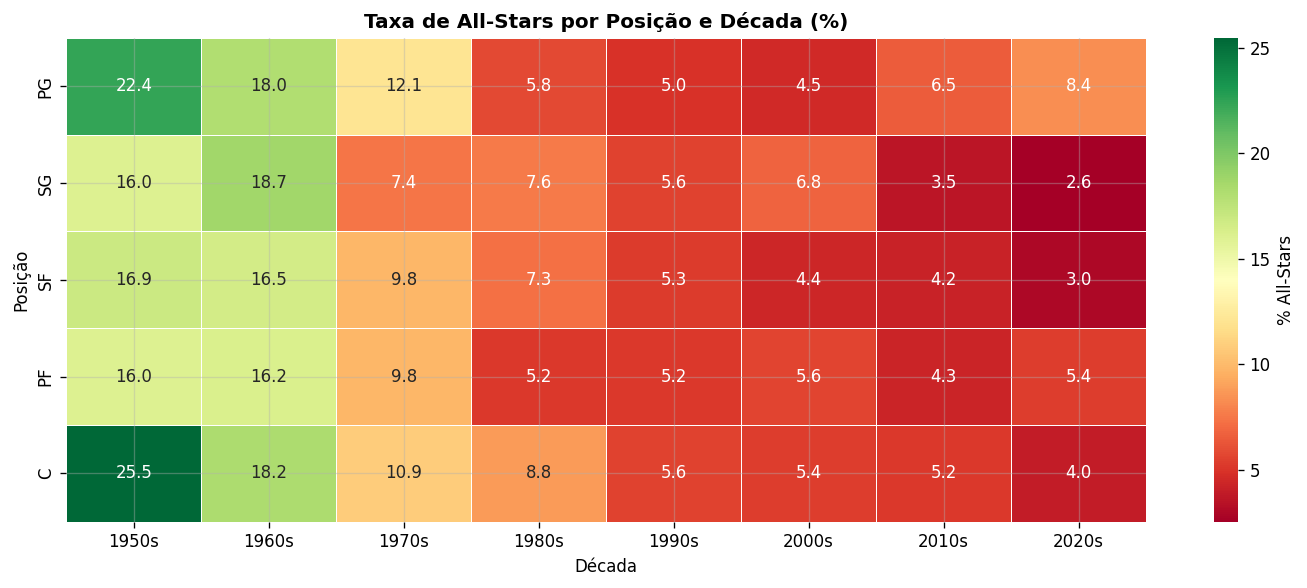

In [13]:
# Taxa de All-Stars por Posição e Década
# Mostra quais posições foram mais valorizadas em cada época da NBA

pivot_as = df_pos.groupby(['pos','decade'])['is_allstar'].apply(
    lambda x: x.astype(float).mean() * 100
).unstack()
pivot_as = pivot_as.reindex(index=pos_order, columns=decadas)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_as, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5, linecolor='white', cbar_kws={'label': '% All-Stars'}, ax=ax)
ax.set_title('Taxa de All-Stars por Posição e Década (%)', fontweight='bold', fontsize=12)
ax.set_xlabel('Década')
ax.set_ylabel('Posição')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec4_heatmap_allstar_pos_decada.png', bbox_inches='tight')
plt.show()

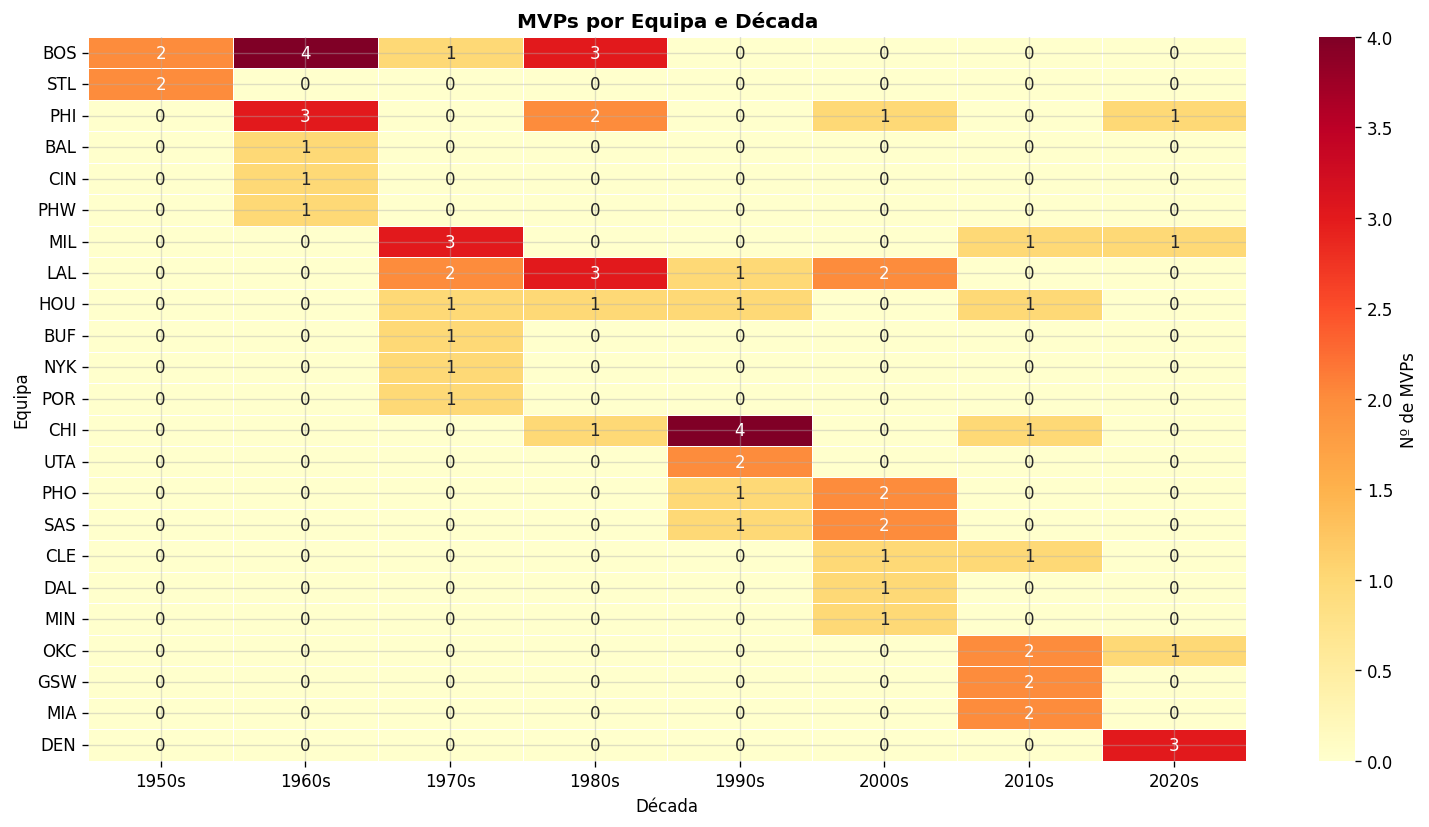

In [14]:
# MVPs por Equipa ao longo das Décadas
# Mostra quais as franquias mais dominantes em termos de prémios MVP

mvp_df = awards_df[awards_df['award'] == 'nba mvp'].copy()
mvp_df = mvp_df[mvp_df['winner'] == True][['player', 'season']].copy()

# Adicionar a equipa do jogador nessa época
mvp_com_equipa = mvp_df.merge(
    df_work[['player','season','team']].drop_duplicates(),
    on=['player','season'], how='left'
)

# Adicionar década
mvp_com_equipa['decade'] = (mvp_com_equipa['season'] // 10 * 10).astype(str) + 's'

# Contar MVPs por equipa e década
pivot_mvp = mvp_com_equipa.groupby(['team','decade']).size().unstack(fill_value=0)

# Filtrar só equipas com pelo menos 1 MVP
pivot_mvp = pivot_mvp[pivot_mvp.sum(axis=1) >= 1].sort_values(
    by=pivot_mvp.columns.tolist(), ascending=False
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_mvp, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Nº de MVPs'}, ax=ax)
ax.set_title('MVPs por Equipa e Década', fontweight='bold', fontsize=12)
ax.set_xlabel('Década')
ax.set_ylabel('Equipa')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec4_heatmap_mvp_equipa.png', bbox_inches='tight')
plt.show()

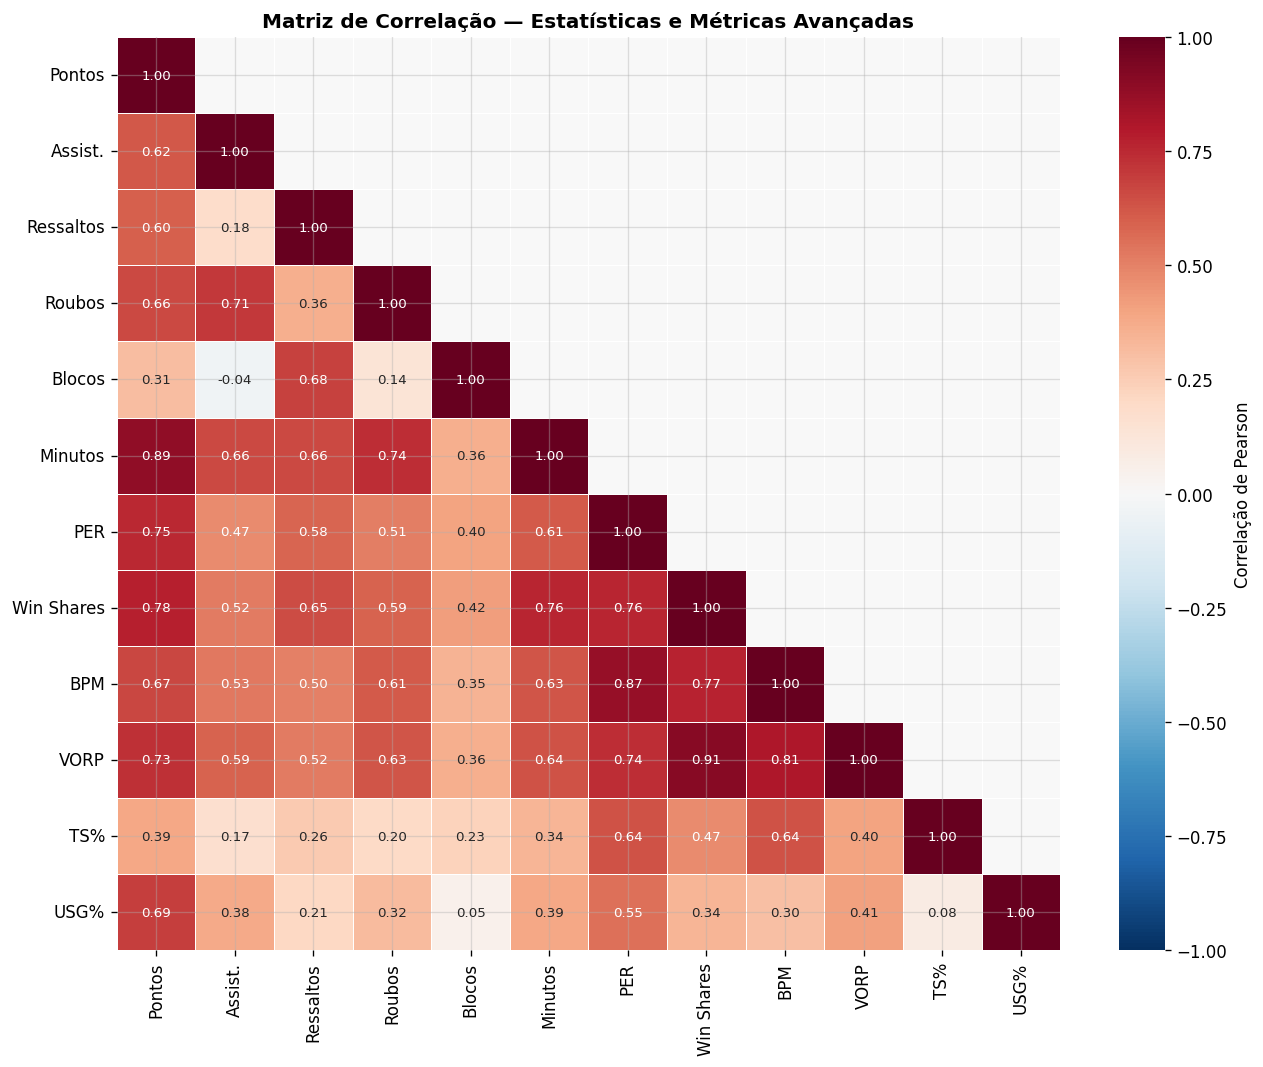

In [15]:
# Matriz de correlação das estatísticas principais

cols_corr = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game',
             'blk_per_game', 'mp_per_game', 'per', 'ws', 'bpm', 'vorp',
             'ts_percent', 'usg_percent']
cols_corr = [c for c in cols_corr if c in df_work.columns]

labels_corr = {
    'pts_per_game': 'Pontos', 'ast_per_game': 'Assist.',
    'trb_per_game': 'Ressaltos', 'stl_per_game': 'Roubos',
    'blk_per_game': 'Blocos', 'mp_per_game': 'Minutos',
    'per': 'PER', 'ws': 'Win Shares', 'bpm': 'BPM',
    'vorp': 'VORP', 'ts_percent': 'TS%', 'usg_percent': 'USG%'
}

corr = df_work[cols_corr].corr().round(2)
corr.index = [labels_corr.get(c, c) for c in corr.index]
corr.columns = [labels_corr.get(c, c) for c in corr.columns]

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Correlação de Pearson'}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlação — Estatísticas e Métricas Avançadas', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec4_heatmap_correlacao.png', bbox_inches='tight')
plt.show()

---
## Evolução Temporal

Os gráficos de linha mostram como o jogo NBA evoluiu ao longo de quase 80 anos. Destacamos momentos históricos com linhas verticais anotadas — introdução do shot clock, da linha de 3 pontos, e outras mudanças de regras que transformaram o jogo.

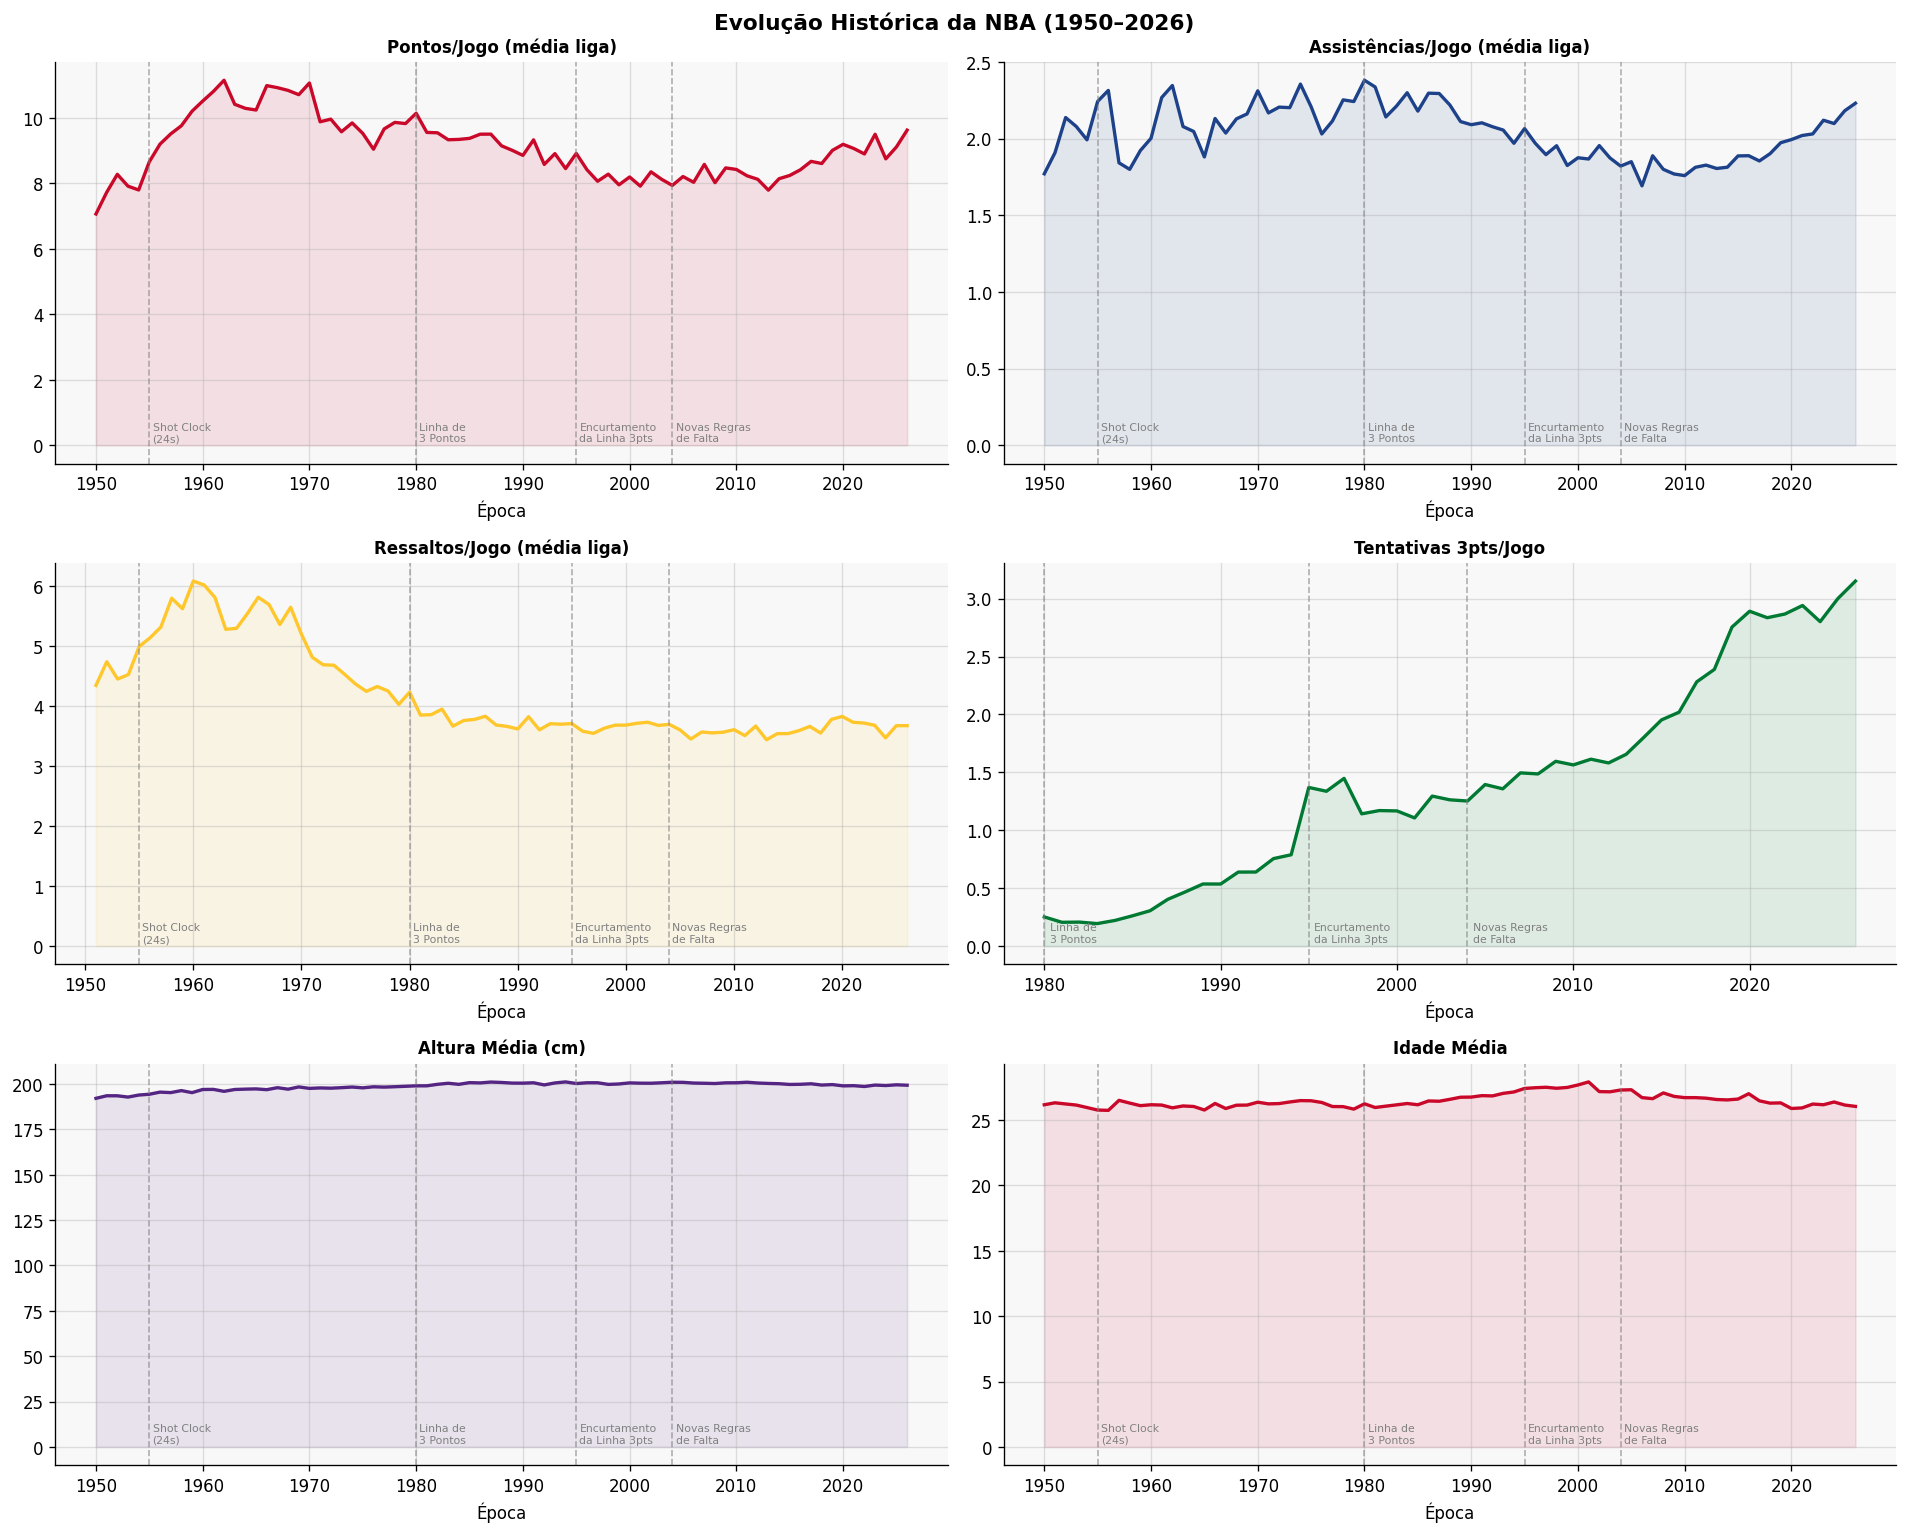

In [16]:
# Evolução das estatísticas ofensivas ao longo das épocas

by_season = df_work.groupby('season').agg(
    pts = ('pts_per_game', 'mean'),
    ast = ('ast_per_game', 'mean'),
    trb = ('trb_per_game', 'mean'),
    x3pa = ('x3pa_per_game','mean'),
    height = ('height_cm', 'mean'),
    age = ('age', 'mean'),
).reset_index()

# Momentos históricos importantes para anotar
marcos = [
    (1955, 'Shot Clock\n(24s)'),
    (1980, 'Linha de\n3 Pontos'),
    (1995, 'Encurtamento\nda Linha 3pts'),
    (2004, 'Novas Regras\nde Falta'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes = axes.flatten()

series = [
    ('pts', 'Pontos/Jogo (média liga)', PALETTE[0]),
    ('ast', 'Assistências/Jogo (média liga)', PALETTE[1]),
    ('trb', 'Ressaltos/Jogo (média liga)', PALETTE[2]),
    ('x3pa', 'Tentativas 3pts/Jogo', PALETTE[3]),
    ('height', 'Altura Média (cm)', PALETTE[4]),
    ('age', 'Idade Média', PALETTE[0]),
]

for i, (col, label, color) in enumerate(series):
    ax = axes[i]
    data = by_season.dropna(subset=[col])
    ax.plot(data['season'], data[col], color=color, linewidth=2)
    ax.fill_between(data['season'], data[col], alpha=0.1, color=color)

    # Adicionar marcos históricos
    for ano, texto in marcos:
        if data['season'].min() <= ano <= data['season'].max():
            ax.axvline(x=ano, color='gray', linestyle='--', linewidth=1, alpha=0.6)
            ax.text(ano + 0.3, ax.get_ylim()[0] +
                    (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05,
                    texto, fontsize=6.5, color='gray', va='bottom')

    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Época')

plt.suptitle('Evolução Histórica da NBA (1950–2026)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec5_evolucao_temporal.png', bbox_inches='tight')
plt.show()

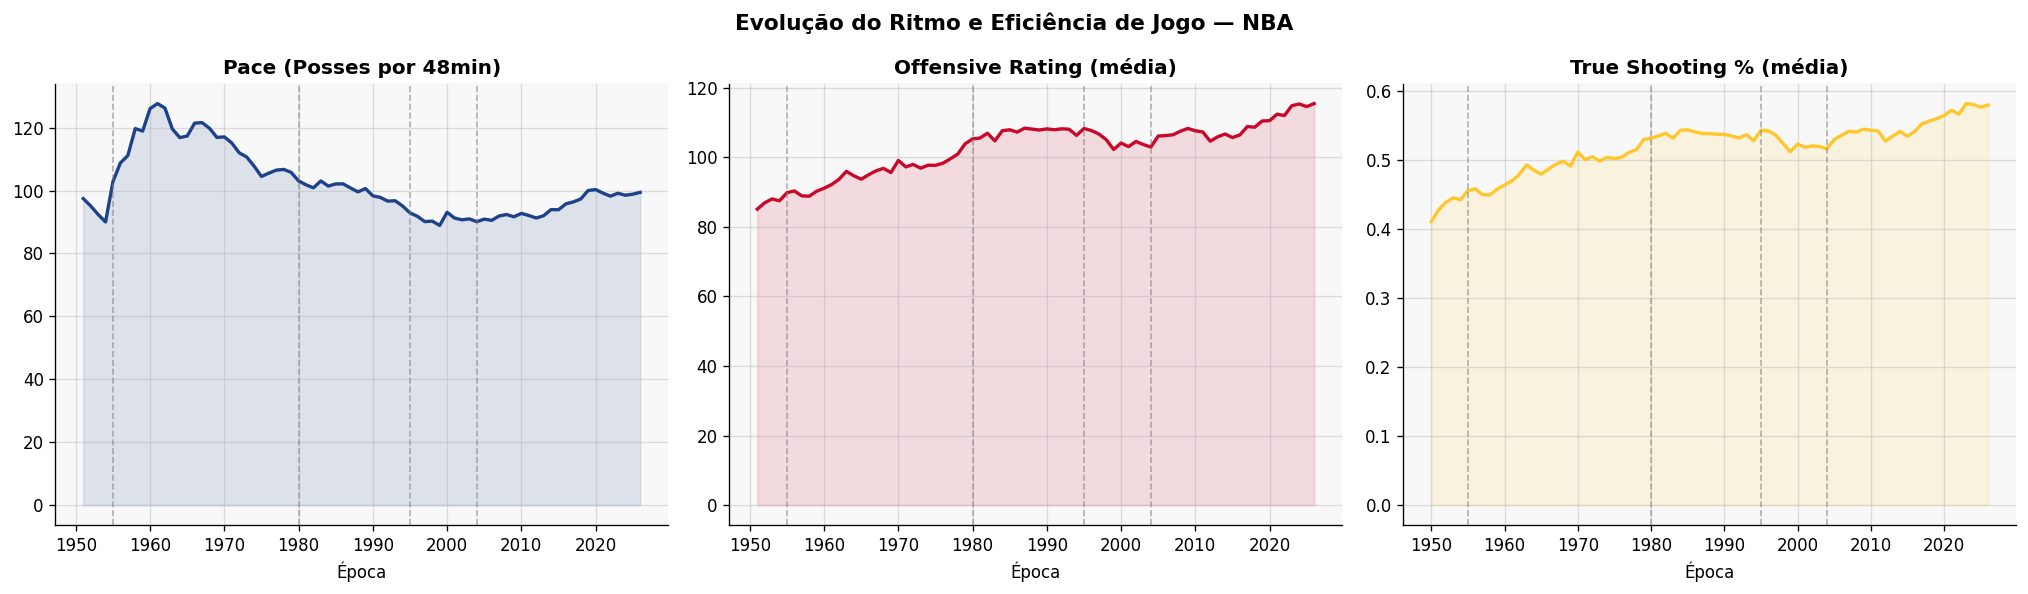

In [17]:
# Evolução do ritmo de jogo (pace) e eficiência ofensiva

pace_season = team_df.groupby('season')[['pace','o_rtg','ts_percent']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metricas_equipa = [
    ('pace', 'Pace (Posses por 48min)', PALETTE[1]),
    ('o_rtg', 'Offensive Rating (média)', PALETTE[0]),
    ('ts_percent', 'True Shooting % (média)', PALETTE[2]),
]

for i, (col, label, color) in enumerate(metricas_equipa):
    ax = axes[i]
    data = pace_season.dropna(subset=[col])
    ax.plot(data['season'], data[col], color=color, linewidth=2)
    ax.fill_between(data['season'], data[col], alpha=0.12, color=color)

    for ano, texto in marcos:
        if data['season'].min() <= ano <= data['season'].max():
            ax.axvline(x=ano, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Época')

plt.suptitle('Evolução do Ritmo e Eficiência de Jogo — NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec5_pace_eficiencia.png', bbox_inches='tight')
plt.show()

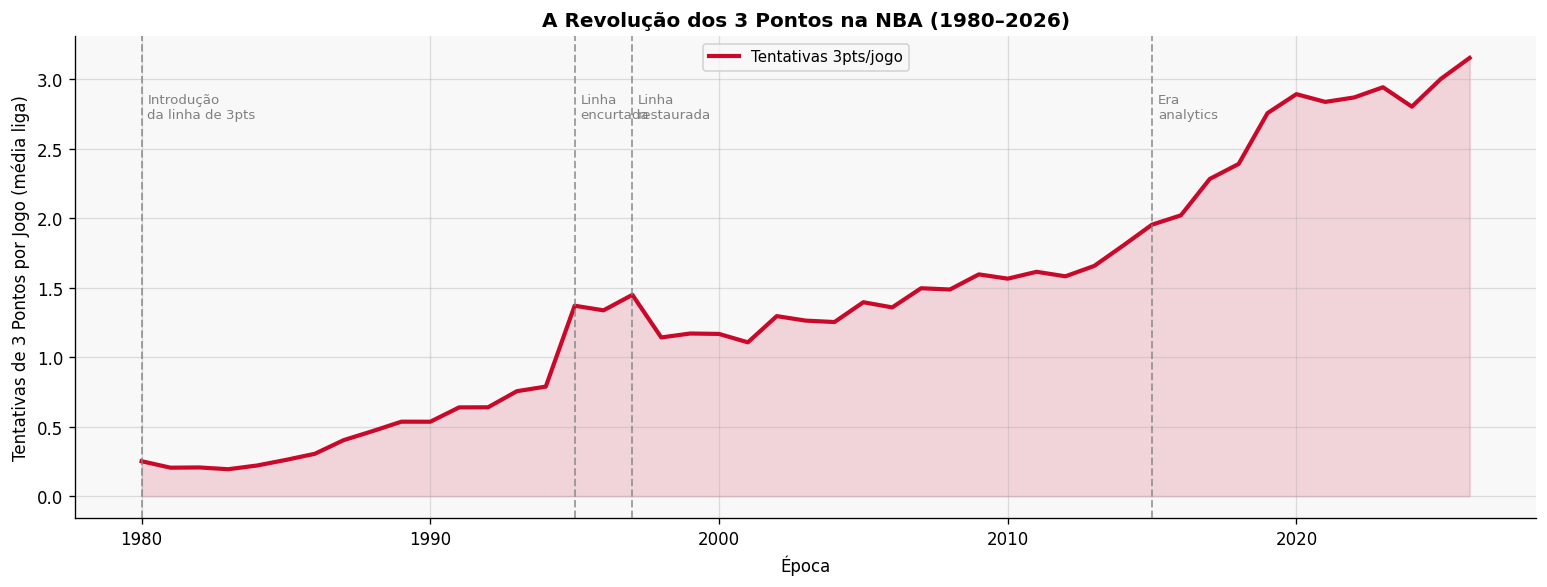

In [18]:
# Evolução da linha de 3 pontos — antes e depois de 1980

df_3pt = by_season[by_season['season'] >= 1980].copy()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_3pt['season'], df_3pt['x3pa'], color=PALETTE[0], linewidth=2.5, label='Tentativas 3pts/jogo')
ax.fill_between(df_3pt['season'], df_3pt['x3pa'], alpha=0.15, color=PALETTE[0])

# Marcos específicos da era do 3 pontos
marcos_3pt = [
    (1980, 'Introdução\nda linha de 3pts'),
    (1995, 'Linha\nencurtada'),
    (1997, 'Linha\nrestaurada'),
    (2015, 'Era\nanalytics'),
]
for ano, texto in marcos_3pt:
    ax.axvline(x=ano, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(ano + 0.2, df_3pt['x3pa'].max() * 0.92, texto, fontsize=8, color='gray', va='top')

ax.set_title('A Revolução dos 3 Pontos na NBA (1980–2026)', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Tentativas de 3 Pontos por Jogo (média liga)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec5_revolucao_3pts.png', bbox_inches='tight')
plt.show()

---
## Rankings Top 10

Gráficos com os melhores jogadores e equipas da história da NBA por diferentes métricas. Os rankings permitem comparar grandezas absolutas de forma imediata e visual.

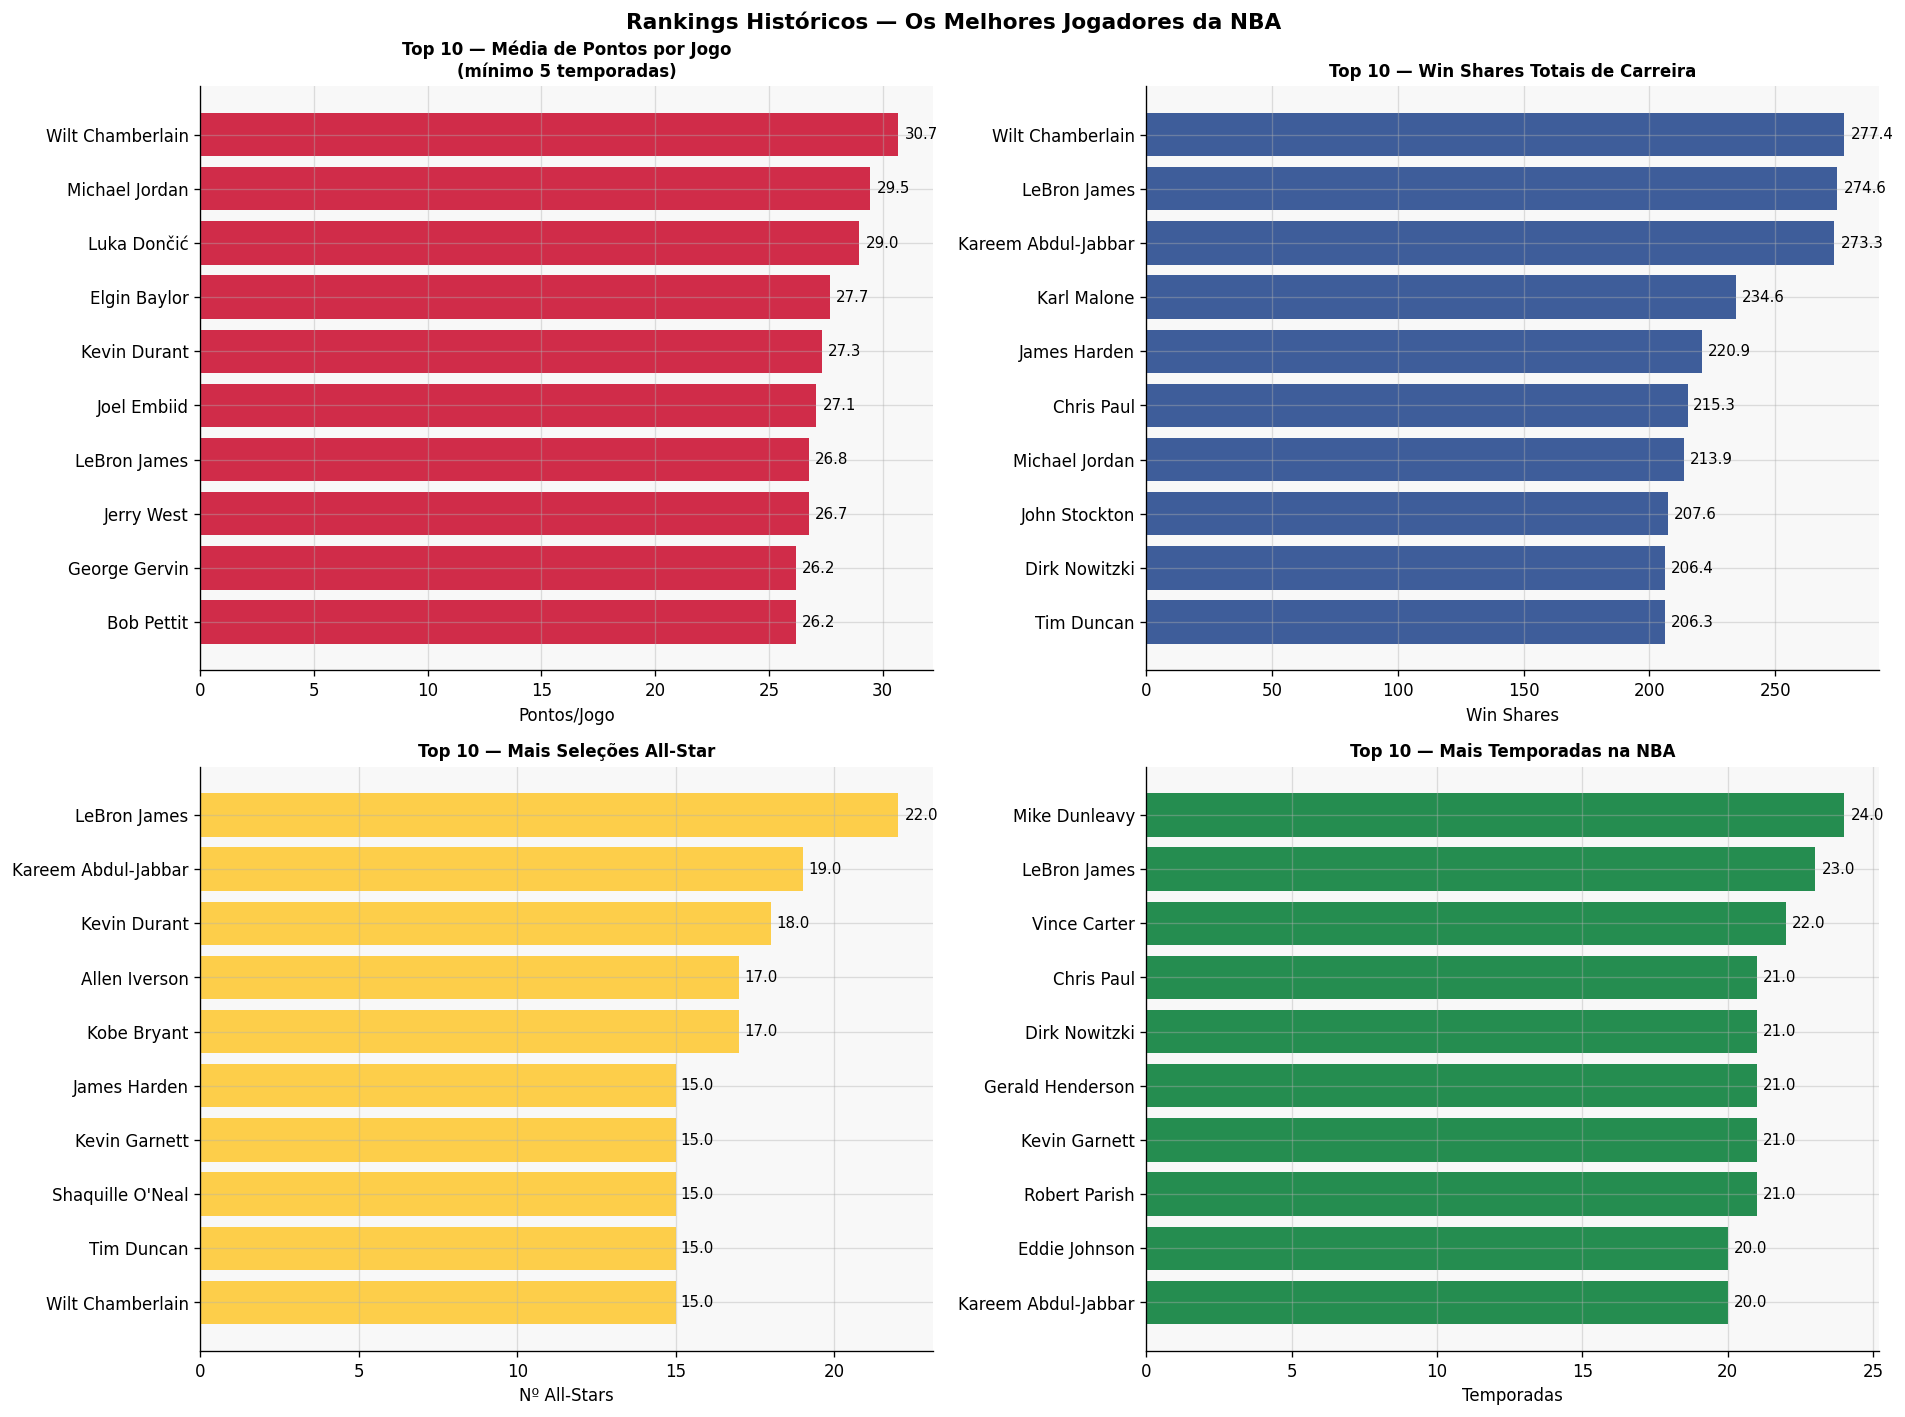

In [19]:
# Rankings de jogadores históricos — 4 métricas diferentes

# Agregar por jogador 
career = df_work.groupby('player').agg(
    pts_medio   = ('pts_per_game', 'mean'),
    ws_total    = ('ws', 'sum'),
    allstar_n   = ('is_allstar','sum'),
    temporadas  = ('season', 'nunique'),
).reset_index()

# Filtrar jogadores com pelo menos 5 temporadas para rankings históricos
career_min = career[career['temporadas'] >= 5].copy()

rankings = [
    ('pts_medio', 'Top 10 — Média de Pontos por Jogo\n(mínimo 5 temporadas)', 'Pontos/Jogo', PALETTE[0]),
    ('ws_total', 'Top 10 — Win Shares Totais de Carreira', 'Win Shares', PALETTE[1]),
    ('allstar_n', 'Top 10 — Mais Seleções All-Star', 'Nº All-Stars', PALETTE[2]),
    ('temporadas', 'Top 10 — Mais Temporadas na NBA', 'Temporadas', PALETTE[3]),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, titulo, xlabel, color) in enumerate(rankings):
    ax = axes[i]
    top10 = career_min.nlargest(10, col)[['player', col]].iloc[::-1]

    bars = ax.barh(top10['player'], top10[col], color=color, alpha=0.85)

    for bar, val in zip(bars, top10[col]):
        ax.text(bar.get_width() + bar.get_width() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=9)

    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel(xlabel)

plt.suptitle('Rankings Históricos — Os Melhores Jogadores da NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec6_rankings_jogadores.png', bbox_inches='tight')
plt.show()

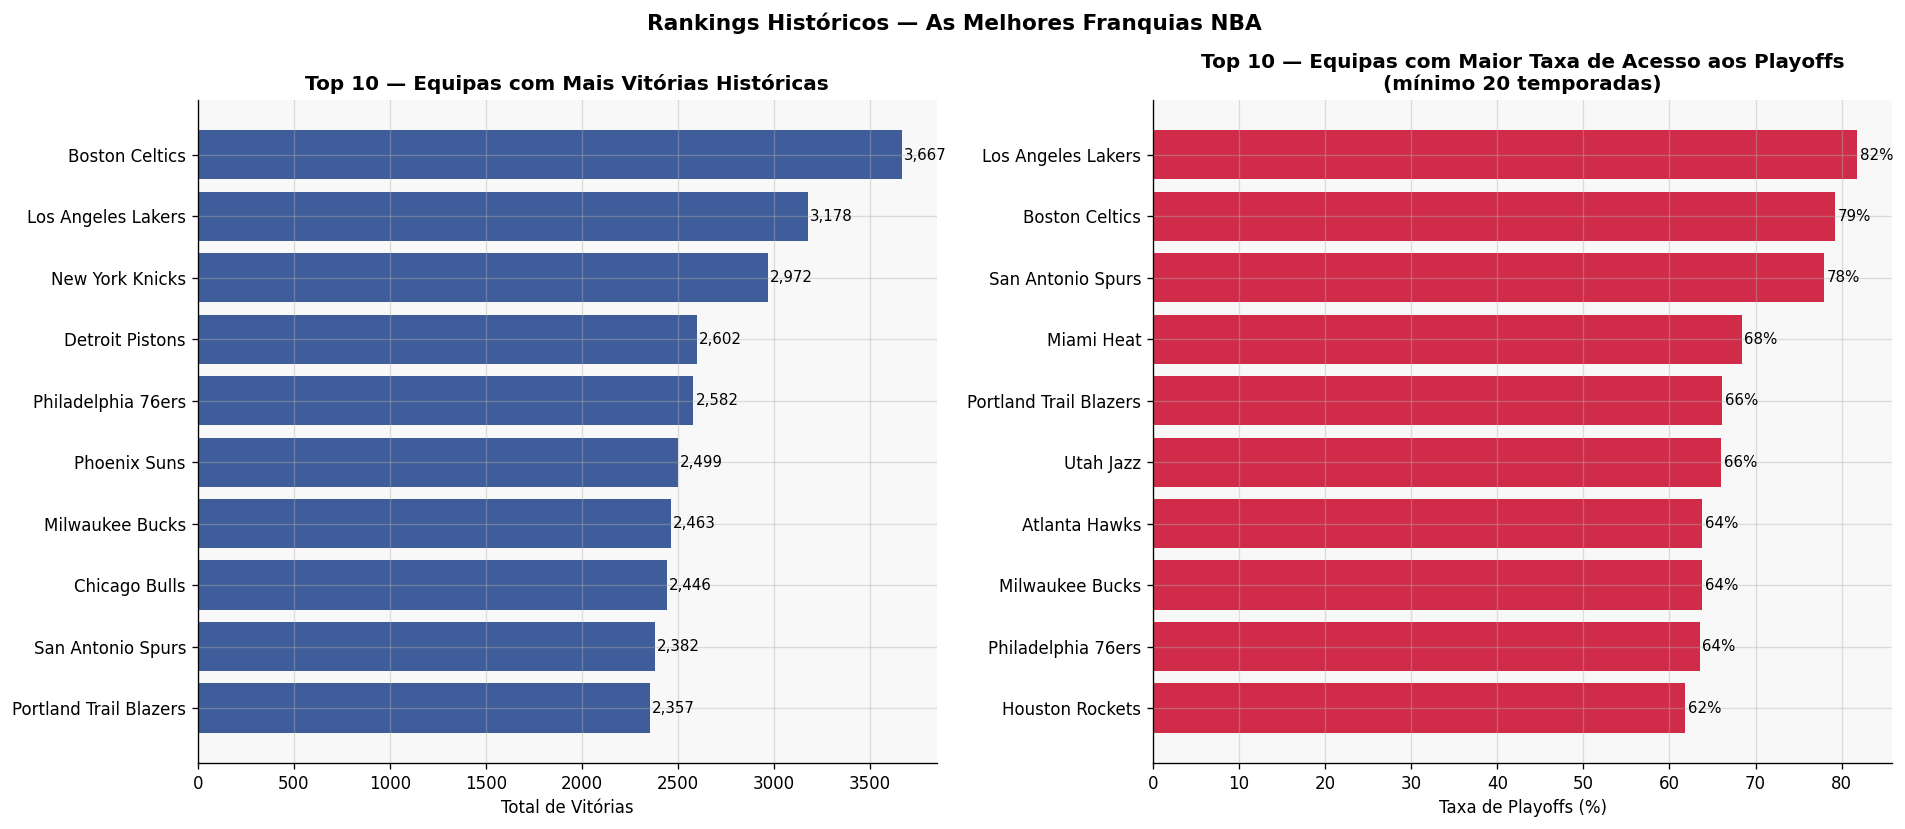

In [20]:
# Rankings de equipas — vitórias históricas e taxa de playoffs

# Total de vitórias por equipa
team_wins = team_df.groupby('team')['w'].sum().reset_index()
team_wins.columns = ['team', 'total_wins']

# Taxa de acesso aos playoffs
team_playoffs_rate = team_df.groupby('team').agg(
    temporadas = ('season',   'nunique'),
    playoffs_n = ('playoffs', 'sum')
).reset_index()
team_playoffs_rate['playoff_rate'] = (
    team_playoffs_rate['playoffs_n'] / team_playoffs_rate['temporadas'] * 100
).round(1)

team_playoffs_rate = team_playoffs_rate[team_playoffs_rate['temporadas'] >= 20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 vitórias
top_wins = team_wins.nlargest(10, 'total_wins').iloc[::-1]
bars = axes[0].barh(top_wins['team'], top_wins['total_wins'], color=PALETTE[1], alpha=0.85)
for bar, val in zip(bars, top_wins['total_wins']):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=9)
axes[0].set_title('Top 10 — Equipas com Mais Vitórias Históricas', fontweight='bold')
axes[0].set_xlabel('Total de Vitórias')

# Top 10 taxa de playoffs
top_rate = team_playoffs_rate.nlargest(10, 'playoff_rate').iloc[::-1]
bars2 = axes[1].barh(top_rate['team'], top_rate['playoff_rate'], color=PALETTE[0], alpha=0.85)
for bar, val in zip(bars2, top_rate['playoff_rate']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}%', va='center', fontsize=9)
axes[1].set_title('Top 10 — Equipas com Maior Taxa de Acesso aos Playoffs\n(mínimo 20 temporadas)', fontweight='bold')
axes[1].set_xlabel('Taxa de Playoffs (%)')

plt.suptitle('Rankings Históricos — As Melhores Franquias NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec6_rankings_equipas.png', bbox_inches='tight')
plt.show()

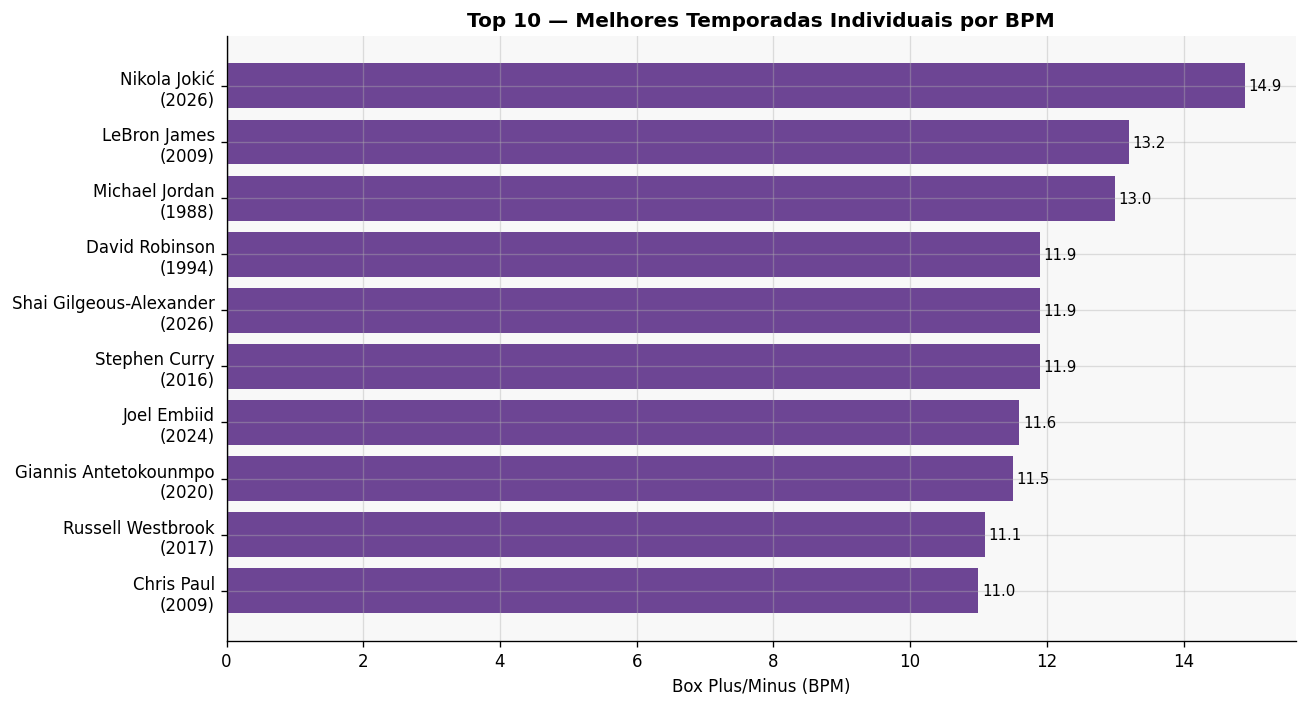

In [21]:
# Ranking do BPM máximo — os jogadores com melhor temporada individual

best_season = df_work.dropna(subset=['bpm']).copy()
# Melhor temporada de cada jogador
best_season = best_season.loc[best_season.groupby('player')['bpm'].idxmax()]
top_bpm = best_season.nlargest(10, 'bpm')[['player','season','bpm','pts_per_game']].iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_bpm['player'] + '\n(' + top_bpm['season'].astype(str) + ')',
    top_bpm['bpm'],
    color=PALETTE[4], alpha=0.85
)
for bar, val in zip(bars, top_bpm['bpm']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_title('Top 10 — Melhores Temporadas Individuais por BPM', fontweight='bold', fontsize=12)
ax.set_xlabel('Box Plus/Minus (BPM)')
ax.axvline(x=0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec6_ranking_bpm.png', bbox_inches='tight')
plt.show()

---
## Análise de All-Stars e MVP

Visualizações dedicadas ao reconhecimento individual — os prémios mais importantes da NBA. Analisamos quem foram os jogadores mais reconhecidos, como o reconhecimento se distribui por posição e era, e a relação entre os votos MVP e a performance real.

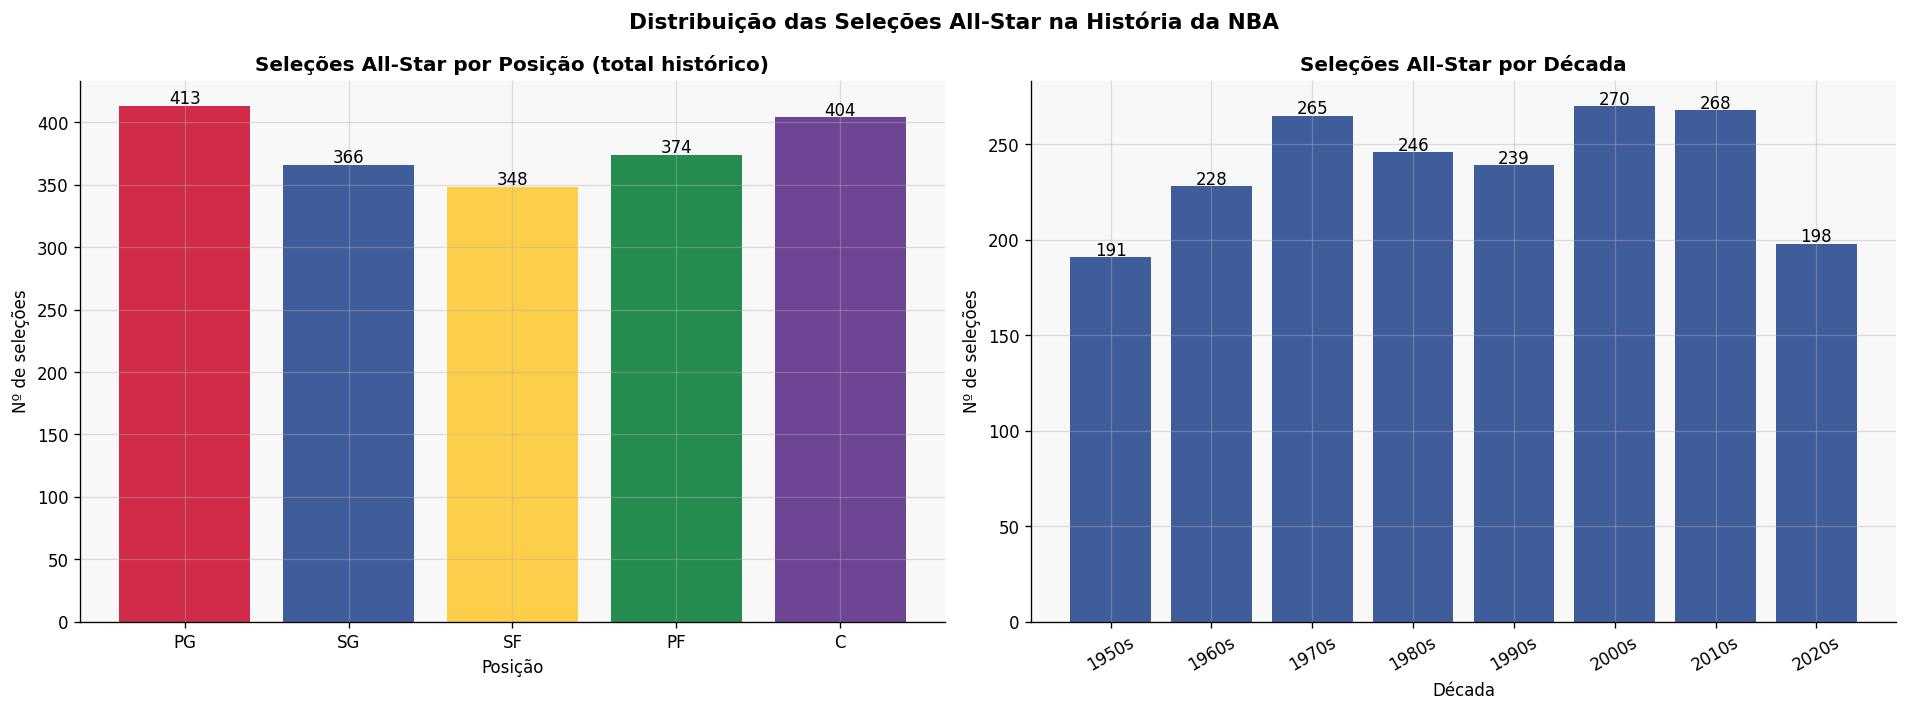

In [22]:
# All-Stars por posição e por década

pos_order = ['PG', 'SG', 'SF', 'PF', 'C']
decadas = ['1950s','1960s','1970s','1980s','1990s','2000s','2010s','2020s']

allstars_df = df_work[
    (df_work['is_allstar'].astype(bool) == True) &
    (df_work['pos'].isin(pos_order))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 — All-Stars por posição
as_pos = allstars_df['pos'].value_counts().reindex(pos_order)
bars = axes[0].bar(pos_order, as_pos.values, color=PALETTE[:5], alpha=0.85)
for bar, val in zip(bars, as_pos.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(val)), ha='center', fontsize=10)
axes[0].set_title('Seleções All-Star por Posição (total histórico)', fontweight='bold')
axes[0].set_xlabel('Posição')
axes[0].set_ylabel('Nº de seleções')

# Gráfico 2 — All-Stars por década
as_dec = allstars_df['decade'].value_counts().reindex(decadas)
bars2 = axes[1].bar(decadas, as_dec.values, color=PALETTE[1], alpha=0.85)
for bar, val in zip(bars2, as_dec.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(val)), ha='center', fontsize=10)
axes[1].set_title('Seleções All-Star por Década', fontweight='bold')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Nº de seleções')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Distribuição das Seleções All-Star na História da NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec7_allstar_pos_decada.png', bbox_inches='tight')
plt.show()

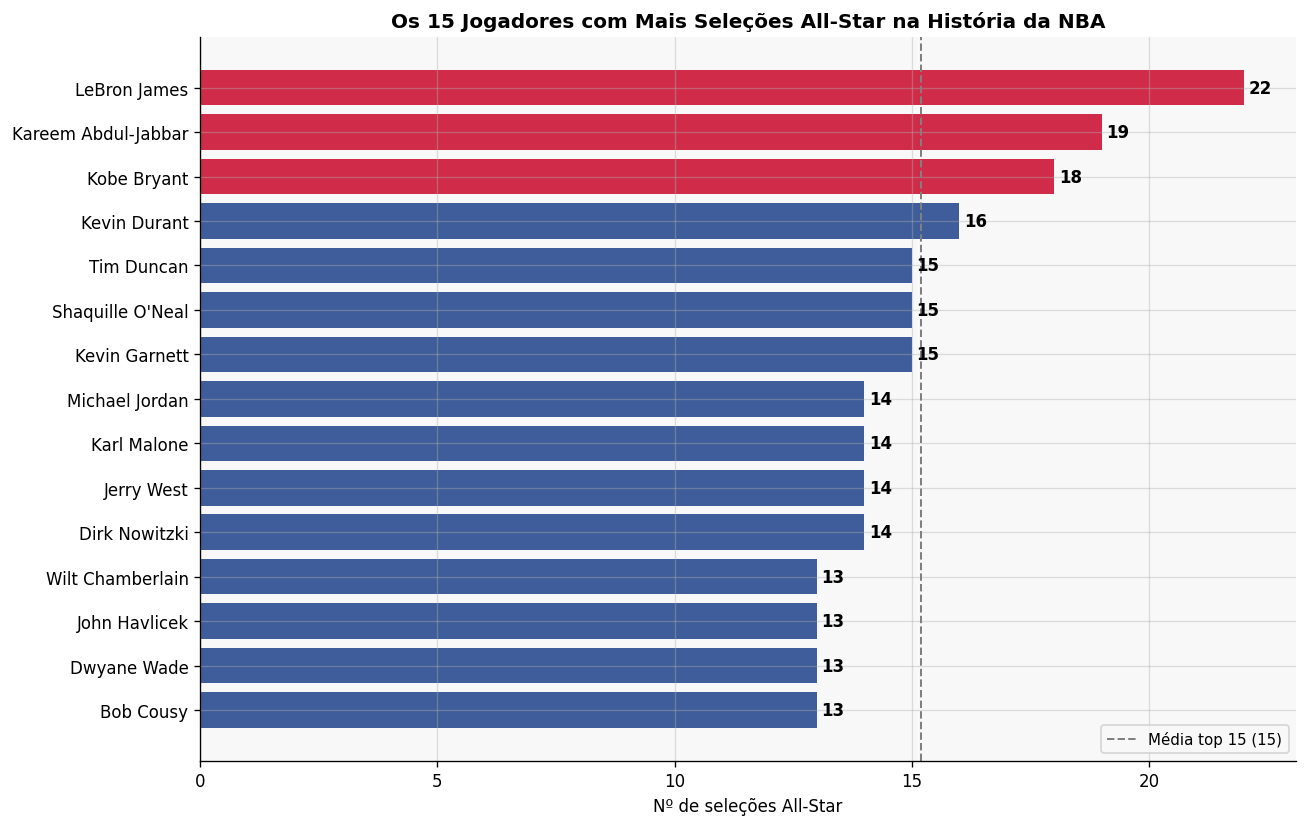

In [23]:
# Top 15 jogadores com mais seleções All-Star na história

top_allstar = allstar_df[allstar_df['lg'] == 'NBA'].groupby('player').size()\
                         .nlargest(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [PALETTE[0] if i >= 12 else PALETTE[1] for i in range(len(top_allstar))]
bars = ax.barh(top_allstar.index, top_allstar.values, color=colors, alpha=0.85)

for bar, val in zip(bars, top_allstar.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=10, fontweight='bold')

ax.set_title('Os 15 Jogadores com Mais Seleções All-Star na História da NBA', fontweight='bold', fontsize=12)
ax.set_xlabel('Nº de seleções All-Star')
ax.axvline(x=top_allstar.mean(), color='gray', linestyle='--', linewidth=1.2, label=f'Média top 15 ({top_allstar.mean():.0f})')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec7_top_allstars.png', bbox_inches='tight')
plt.show()

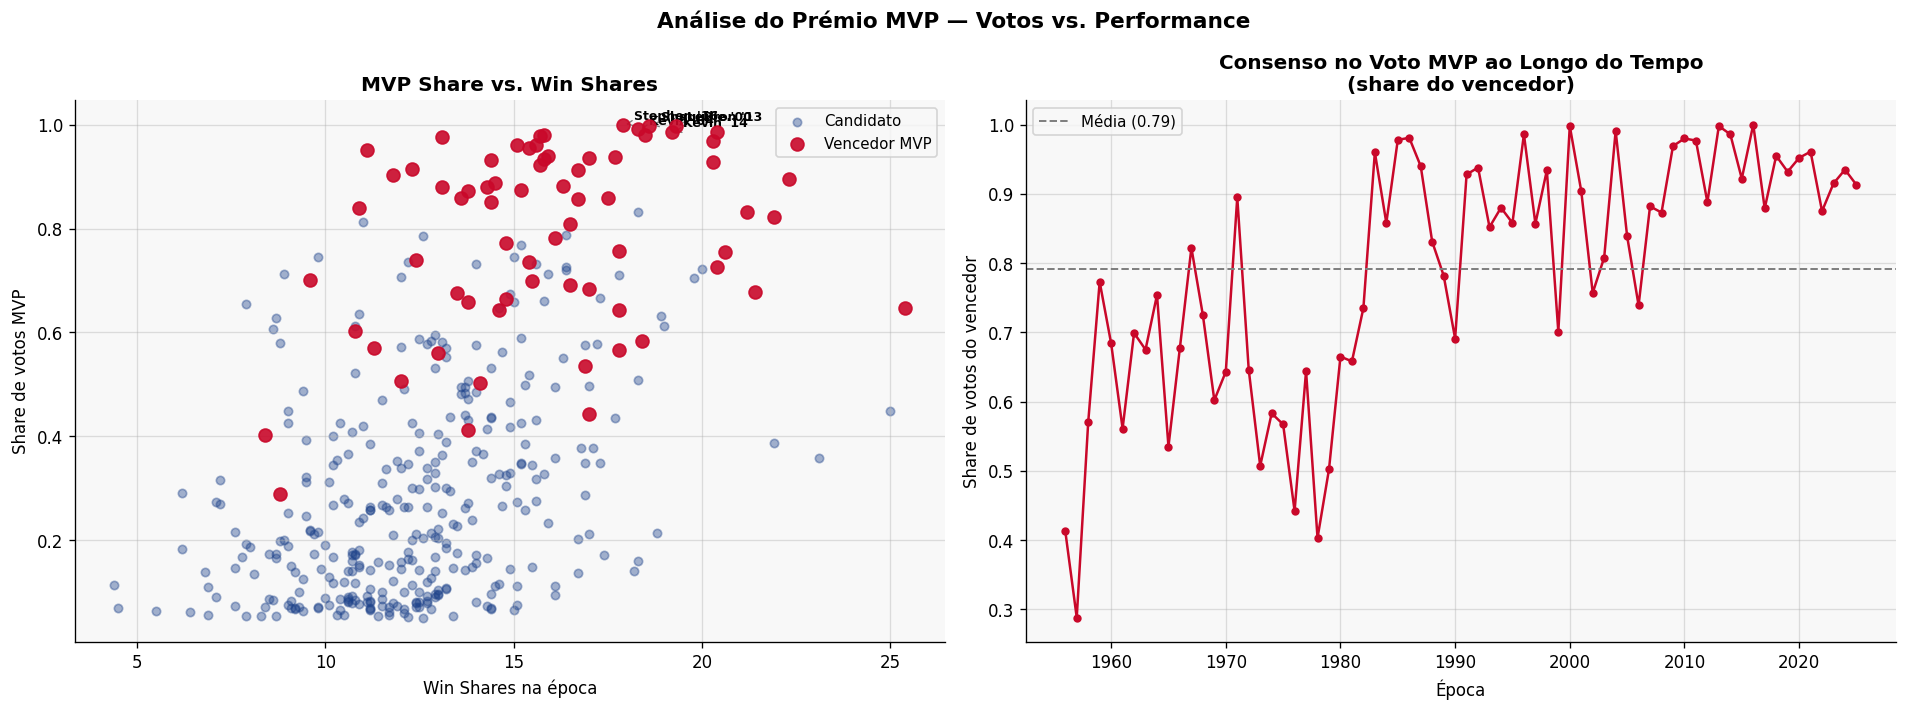

In [24]:
# MVP Share vs. Win Shares — a relação entre votos e performance real
# Mostra se os votantes escolhem os jogadores com maior impacto real

mvp_df = awards_df[awards_df['award'] == 'nba mvp'].copy()
mvp_df = mvp_df[mvp_df['share'] > 0.05]  # só quem recebeu votos relevantes

# Juntar com Win Shares do dataset principal
mvp_merged = mvp_df.merge(
    df_work[['player','season','ws','pts_per_game','per']].drop_duplicates(),
    on=['player','season'], how='left'
).dropna(subset=['ws'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 — MVP Share vs. Win Shares
winners  = mvp_merged[mvp_merged['winner'] == True]
nwinners = mvp_merged[mvp_merged['winner'] == False]

axes[0].scatter(nwinners['ws'], nwinners['share'], color=PALETTE[1], alpha=0.4, s=25, label='Candidato')
axes[0].scatter(winners['ws'],  winners['share'], color=PALETTE[0], alpha=0.9, s=60, label='Vencedor MVP', zorder=5)

# Anotar alguns MVPs famosos
for _, row in winners.nlargest(5, 'share').iterrows():
    nome = row['player'].split()[0]
    axes[0].annotate(f"{nome} '{str(row['season'])[2:]}",
                     xy=(row['ws'], row['share']),
                     xytext=(row['ws'] + 0.3, row['share'] + 0.01),
                     fontsize=7.5, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

axes[0].set_xlabel('Win Shares na época')
axes[0].set_ylabel('Share de votos MVP')
axes[0].set_title('MVP Share vs. Win Shares', fontweight='bold')
axes[0].legend(fontsize=9)

# Gráfico 2 — Mostra se os MVPs têm sido escolhidos por unanimidade ou com disputa
winner_share_season = winners.sort_values('season')
axes[1].plot(winner_share_season['season'], winner_share_season['share'], color=PALETTE[0], linewidth=1.5, marker='o', markersize=4)
axes[1].axhline(y=winner_share_season['share'].mean(), color='gray',
                linestyle='--', linewidth=1.2,
                label=f"Média ({winner_share_season['share'].mean():.2f})")
axes[1].set_title('Consenso no Voto MVP ao Longo do Tempo\n(share do vencedor)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Share de votos do vencedor')
axes[1].legend(fontsize=9)

plt.suptitle('Análise do Prémio MVP — Votos vs. Performance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec7_mvp_analise.png', bbox_inches='tight')
plt.show()

---
## Análise Crítica

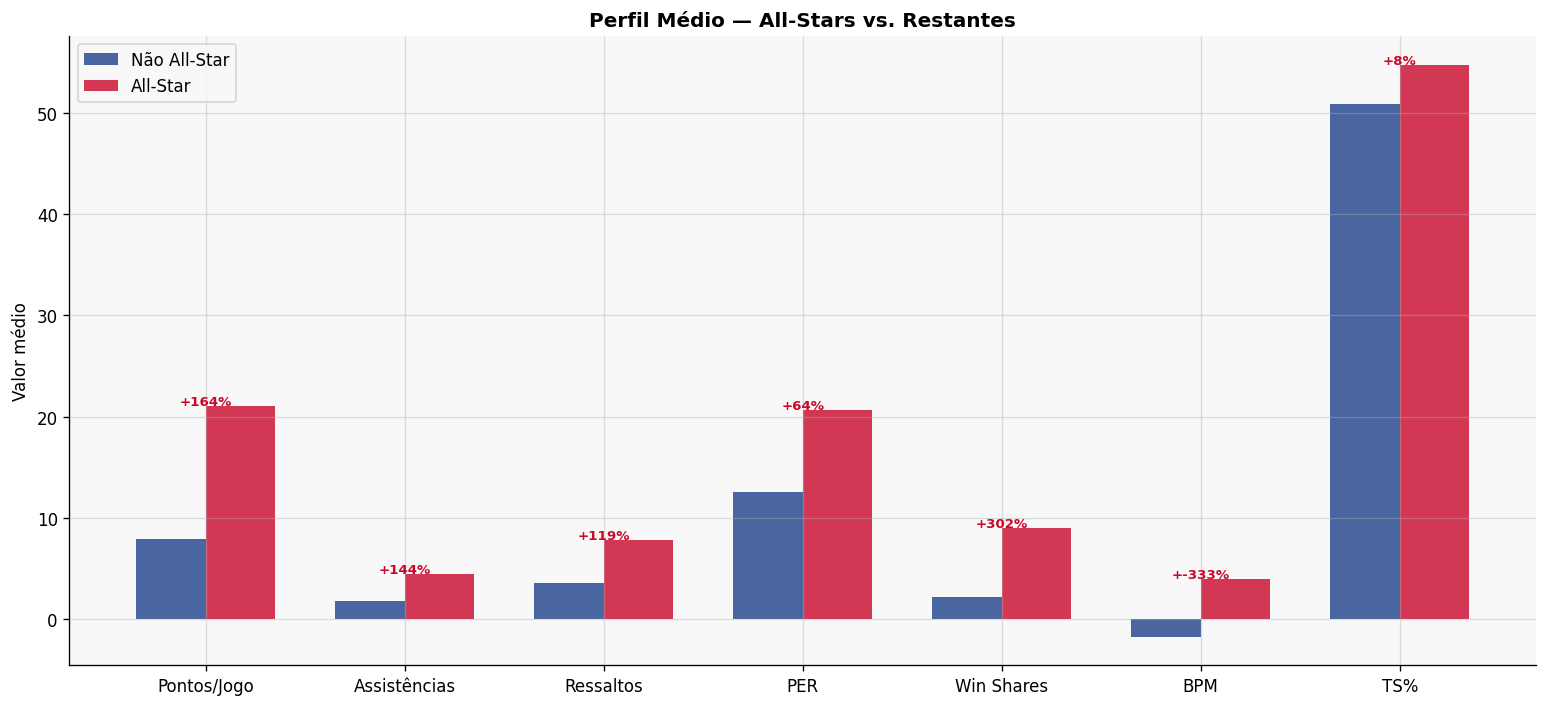

In [25]:
# Resumo visual das principais conclusões 
# Comparação das médias dos All-Stars vs. restantes nas métricas mais discriminativas

allstars = df_work[df_work['is_allstar'].astype(bool) == True]
normais  = df_work[df_work['is_allstar'].astype(bool) == False]

metricas = {
    'Pontos/Jogo': ('pts_per_game', 1.0),
    'Assistências': ('ast_per_game', 1.0),
    'Ressaltos': ('trb_per_game', 1.0),
    'PER': ('per', 1.0),
    'Win Shares': ('ws', 1.0),
    'BPM': ('bpm', 1.0),
    'TS%': ('ts_percent', 100.0),
}

labels, vals_as, vals_n = [], [], []
for label, (col, scale) in metricas.items():
    if col in df_work.columns:
        labels.append(label)
        vals_as.append(allstars[col].mean() * scale)
        vals_n.append(normais[col].mean()  * scale)

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - w/2, vals_n,  w, label='Não All-Star', color=PALETTE[1], alpha=0.8)
bars2 = ax.bar(x + w/2, vals_as, w, label='All-Star',     color=PALETTE[0], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Valor médio')
ax.set_title('Perfil Médio — All-Stars vs. Restantes', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)

# Percentagem de diferença por cima de cada par
for b1, b2 in zip(bars1, bars2):
    diff = (b2.get_height() - b1.get_height()) / (b1.get_height() + 1e-9) * 100
    mid  = (b1.get_x() + b2.get_x() + b2.get_width()) / 2
    ax.text(mid, max(b1.get_height(), b2.get_height()) + 0.1,
            f'+{diff:.0f}%', ha='center', fontsize=8, color=PALETTE[0], fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_sec8_sintese_allstar.png', bbox_inches='tight')
plt.show()

### Conclusões Principais

---

1. O que distingue um All-Star é mais do que pontuar:
Os histogramas e o gráfico síntese mostram que os All-Stars são superiores em todas as métricas — não apenas pontos. A diferença mais expressiva está nas métricas avançadas (BPM, Win Shares, PER), o que sugere que os votantes reconhecem o impacto global do jogador no jogo, não apenas a pontuação.

---

2. O jogo mudou radicalmente a partir de 2015:
A evolução temporal mostra uma quebra clara na era moderna: as tentativas de 3 pontos explodiram após 2015, o pace aumentou e a eficiência ofensiva atingiu máximos históricos. A análise por décadas nos boxplots confirma que comparar estatísticas brutas entre eras diferentes não é direto — é necessário normalizar pelo contexto (daí os z-scores criados no notebook 03).

---

3. Cada posição tem um perfil estatístico distinto:
Os boxplots por posição e o heatmap posição × década mostram que os bases (PG) lideram nas assistências enquanto os centros (C) dominam nos ressaltos e blocos. Curiosamente, a distinção entre posições tem vindo a esbater-se na era moderna com o conceito de *positionless basketball* — os extremos (SF) têm cada vez mais assistências e os bases cada vez mais ressaltos.

---

4. Longevidade e reconhecimento andam de mãos dadas:
O ranking de All-Stars é dominado por jogadores com carreiras muito longas — LeBron James com 22 seleções é também o jogador com mais temporadas de alto nível. O scatter plot de idade vs. pontos mostra que os All-Stars mantêm a produção por mais tempo do que os jogadores comuns, o que sugere que o reconhecimento acumula com a carreira.

---

5. Os votos MVP nem sempre seguem a performance:
O scatter plot MVP Share vs. Win Shares revela que, embora haja uma correlação positiva, existem vencedores MVP com Win Shares relativamente baixos e candidatos com Win Shares altos que nunca venceram. Isto indica que fatores narrativos (equipa, contexto da época, impacto mediático) também influenciam os votos — o que torna a previsão do MVP um problema interessante para os modelos ML da Parte II.